# LAPORAN TUGAS BESAR KECERDASAN ARTIFISIAL
### Penerapan Algoritma K-Nearest Neighbors (KNN), Decision Tree, dan Linear Regression dengan Optimasi Genetic Algorithm (GA) untuk Prediksi Harga Rumah
*House Price Regression Dataset*

### Anggota Kelompok

* Dimas Muhammad akbar(103012300155)
* Muhammad Iqbal Tsany Putra (103012300397)
* Arya Danuharja (103012300325)

Mata Kuliah: CAK3DAB3 - Kecerdasan Artifisial  
Kelas:  IF-47-01


# 1. PENDAHULUAN

## 1.1 Latar Belakang

Prediksi harga rumah merupakan aspek penting dalam sektor properti karena dipengaruhi oleh berbagai faktor seperti karakteristik bangunan, lokasi, dan kondisi ekonomi. Akurasi prediksi sangat dibutuhkan oleh pembeli untuk menilai kewajaran harga, oleh penjual untuk menentukan harga yang kompetitif, oleh investor untuk mengidentifikasi peluang apresiasi nilai, serta oleh lembaga keuangan dalam menilai risiko kredit KPR.

Pemanfaatan Kecerdasan Artifisial, khususnya machine learning, memungkinkan prediksi harga rumah yang lebih objektif dan akurat dibandingkan metode tradisional. Pendekatan ini mampu menganalisis pola kompleks dari data historis secara konsisten. Dalam penelitian ini, digunakan tiga algoritma machine learning—K-Nearest Neighbors, Decision Tree, dan Linear Regression—yang performanya dibandingkan dan dioptimasi menggunakan Genetic Algorithm melalui proses feature selection dan hyperparameter tuning.

## 1.2 Penjelasan Algoritma

Untuk mencapai akurasi prediksi yang optimal, penelitian ini mengintegrasikan tiga algoritma machine learning utama yang dioptimasi menggunakan Genetic Algorithm:

### 1.2.1 K-Nearest Neighbors (KNN)

KNN adalah algoritma berbasis *instance-based learning* yang bekerja dengan prinsip kemiripan data. Algoritma ini memprediksi nilai target suatu data baru dengan melihat karakteristik tetangga terdekatnya dalam ruang fitur multidimensi.

Cara Kerja KNN untuk Regresi:
1. Menghitung jarak antara data baru dengan seluruh data training
2. Memilih K tetangga terdekat berdasarkan jarak terkecil
3. Menghitung rata-rata (atau rata-rata tertimbang) nilai target dari K tetangga tersebut
4. Hasil rata-rata menjadi nilai prediksi untuk data baru

Metrik Jarak yang Digunakan:
- Euclidean Distance: $d = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$ — Jarak garis lurus dalam ruang multidimensi
- Manhattan Distance: $d = \sum_{i=1}^{n}|x_i - y_i|$ — Jumlah selisih absolut setiap dimensi

Parameter Penting:
- n_neighbors (K): Jumlah tetangga yang dipertimbangkan. K kecil → sensitif terhadap noise, K besar → lebih smooth tapi kurang detail
- weights: `uniform` (semua tetangga sama pentingnya) atau `distance` (tetangga lebih dekat lebih berpengaruh)
- p: Menentukan metrik jarak (p=1 Manhattan, p=2 Euclidean)



### 1.2.2 Decision Tree

Decision Tree adalah algoritma yang membangun model prediksi dalam bentuk struktur pohon keputusan. Algoritma ini bekerja dengan membagi data secara rekursif berdasarkan fitur yang paling informatif.

Cara Kerja Decision Tree untuk Regresi:
1. Memilih fitur dan threshold terbaik untuk membagi data (berdasarkan kriteria seperti MSE)
2. Membagi data menjadi dua subset berdasarkan kondisi tersebut
3. Mengulangi proses secara rekursif pada setiap subset
4. Berhenti ketika mencapai kondisi tertentu (max depth, min samples, dll)
5. Prediksi = rata-rata nilai target pada leaf node

Parameter Penting:
- max_depth: Kedalaman maksimum pohon. Terlalu dalam → overfitting, terlalu dangkal → underfitting
- min_samples_split: Minimum sampel yang diperlukan untuk melakukan split
- min_samples_leaf: Minimum sampel yang harus ada di setiap leaf node
- criterion: Fungsi untuk mengukur kualitas split (`squared_error` atau `absolute_error`)

Kelebihan: Mudah diinterpretasi, tidak memerlukan scaling, dapat menangkap hubungan non-linear

Kekurangan: Rentan overfitting jika tidak dikontrol dengan baik

### 1.2.3 Linear Regression

Linear Regression adalah algoritma yang memodelkan hubungan linear antara variabel independen (fitur) dan variabel dependen (target).

Formula Model:
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

Dimana:
- $\hat{y}$ = nilai prediksi (harga rumah)
- $\beta_0$ = intercept (konstanta)
- $\beta_i$ = koefisien untuk fitur ke-i
- $x_i$ = nilai fitur ke-i

Cara Kerja:
1. Mencari nilai koefisien ($\beta$) yang meminimalkan Sum of Squared Errors (SSE)
2. Menggunakan metode Ordinary Least Squares (OLS) atau gradient descent
3. Prediksi dilakukan dengan mensubstitusi nilai fitur ke dalam persamaan

Kelebihan: Sederhana, cepat, mudah diinterpretasi, tidak overfitting jika data linear

Kekurangan: Hanya dapat menangkap hubungan linear, sensitif terhadap outlier


### 1.2.4 Genetic Algorithm (GA)

Genetic Algorithm adalah metode optimasi yang terinspirasi dari proses evolusi biologis. GA digunakan untuk mencari solusi optimal dari ruang pencarian yang besar.

Komponen Utama GA:

| Komponen | Analogi Biologis | Fungsi dalam ML |
|----------|------------------|------------------|
| Kromosom | DNA | Representasi solusi (kombinasi fitur + hyperparameter) |
| Gen | Gen dalam DNA | Setiap elemen dalam kromosom (1 fitur atau 1 parameter) |
| Populasi | Populasi makhluk hidup | Kumpulan kandidat solusi |
| Fitness | Kemampuan bertahan | Performa model (RMSE validation) |
| Seleksi | Seleksi alam | Memilih individu terbaik untuk reproduksi |
| Crossover | Perkawinan | Menggabungkan gen dari 2 parent |
| Mutasi | Mutasi genetik | Perubahan random pada gen |
| Elitisme | Survivor | Menjaga individu terbaik tetap ada |

Proses Evolusi GA:
1. Inisialisasi populasi random
2. Evaluasi fitness setiap individu
3. LOOP selama n generasi:
   a. Seleksi parent (tournament selection)
   b. Crossover untuk menghasilkan offspring
   c. Mutasi pada offspring
   d. Evaluasi fitness offspring
   e. Elitisme: pertahankan individu terbaik
4. Return individu dengan fitness terbaik

Penggunaan GA dalam Penelitian Ini:
- Feature Selection: Memilih subset fitur terbaik (bit mask: 1 = gunakan, 0 = tidak)
- Hyperparameter Tuning: Mencari kombinasi parameter optimal untuk setiap model




## 1.3 Rumusan Masalah

Berdasarkan latar belakang yang telah diuraikan, penelitian ini merumuskan beberapa permasalahan utama yang akan dijawab:

1. Bagaimana membangun model machine learning yang dapat memprediksi harga rumah dengan akurat?
   - Investigasi karakteristik data dan hubungan antar variabel
   - Pemilihan algoritma yang sesuai dengan karakteristik data
   - Evaluasi performa model menggunakan metrik yang tepat

2. Bagaimana Genetic Algorithm dapat digunakan untuk mengoptimasi pemilihan fitur dan hyperparameter model?
   - Desain representasi kromosom yang efektif
   - Penentuan parameter GA yang optimal
   - Analisis konvergensi proses evolusi

3. Model mana yang memberikan performa terbaik untuk kasus prediksi harga rumah?
   - Perbandingan tiga algoritma: KNN, Decision Tree, dan Linear Regression
   - Analisis trade-off antara kompleksitas dan akurasi
   - Evaluasi kemampuan generalisasi pada data testing


## 1.4 Tujuan

Penelitian ini bertujuan untuk:

1. Mengimplementasikan tiga model machine learning untuk prediksi harga rumah:
   - K-Nearest Neighbors (KNN): Model berbasis instance yang memprediksi berdasarkan kemiripan dengan data training
   - Decision Tree: Model berbasis aturan yang membuat keputusan berdasarkan pemisahan fitur
   - Linear Regression: Model yang mengasumsikan hubungan linear antara fitur dan target

2. Menggunakan Genetic Algorithm (GA) untuk optimasi otomatis:
   - Feature Selection: Memilih subset fitur yang paling relevan dan menghilangkan fitur yang tidak berkontribusi atau redundan
   - Hyperparameter Tuning: Mencari kombinasi parameter optimal untuk setiap model tanpa exhaustive search

3. Membandingkan performa ketiga model dan menentukan model terbaik berdasarkan:
   - Metrik evaluasi: RMSE, MAE, R², MAPE
   - Kemampuan generalisasi pada data yang belum pernah dilihat
   - Analisis overfitting dan stabilitas prediksi




# 2. SUMBER DAN PAPARAN DATA

## 2.1 Sumber Dataset

Data yang digunakan dalam penelitian ini berasal dari House Price Regression Dataset. Dataset ini dipilih karena memiliki karakteristik yang representatif untuk kasus prediksi harga properti.

Link dataset : https://www.kaggle.com/datasets/prokshitha/home-value-insights

Informasi Dataset:
- Nama: House Price Regression Dataset
- Sumber: Kaggle - Platform dataset untuk machine learning
- Tipe Masalah: Regresi (memprediksi nilai kontinu)
- Jumlah Data: 1.000 baris (sampel rumah)
- Jumlah Variabel: 8 kolom (7 fitur + 1 target)

Dataset ini cocok untuk eksperimen karena:
1. Ukuran data cukup untuk training dan evaluasi model
2. Fitur-fitur yang tersedia relevan dengan faktor penentu harga rumah
3. Data sudah bersih (tidak ada missing values)


## 2.2 Deskripsi Variabel

Dataset ini memiliki 7 variabel prediktor (fitur) dan 1 variabel target. Berikut adalah penjelasan detail untuk setiap variabel:

| No | Variabel | Tipe | Satuan | Deskripsi |
|:--:|:---------|:-----|:-------|:----------|
| 1 | Square_Footage | Numerik (int) | sq ft | Luas bangunan dalam satuan kaki persegi. Fitur ini umumnya memiliki korelasi kuat dengan harga rumah. |
| 2 | Num_Bedrooms | Numerik (int) | unit | Jumlah kamar tidur dalam rumah. Lebih banyak kamar tidur biasanya meningkatkan nilai properti. |
| 3 | Num_Bathrooms | Numerik (int) | unit | Jumlah kamar mandi dalam rumah. Fasilitas kamar mandi mempengaruhi kenyamanan dan nilai rumah. |
| 4 | Year_Built | Numerik (int) | tahun | Tahun rumah dibangun. Rumah baru umumnya memiliki harga lebih tinggi, namun rumah antik juga bisa bernilai tinggi. |
| 5 | Lot_Size | Numerik (float) | acre | Luas tanah/kavling dalam satuan acre. Tanah yang lebih luas memberikan nilai tambah pada properti. |
| 6 | Garage_Size | Numerik (int) | mobil | Kapasitas garasi dalam jumlah mobil (0, 1, atau 2). Garasi merupakan fasilitas yang dicari pembeli. |
| 7 | Neighborhood_Quality | Numerik (int) | skala 1-10 | Skor kualitas lingkungan sekitar. Lingkungan yang baik meningkatkan nilai properti. |
| 8 | House_Price | Numerik (float) | USD ($) | TARGET - Harga jual rumah dalam dolar Amerika. |

Catatan: Semua variabel sudah dalam bentuk numerik sehingga tidak diperlukan proses encoding untuk data kategorikal.


## 2.3 Target Variabel

Variabel yang akan diprediksi dalam penelitian ini adalah House_Price (Harga Rumah).

Karakteristik Target:
- Nama Variabel: `House_Price`
- Tipe Data: Kontinyu (numerik float)
- Satuan: USD (Dolar Amerika Serikat)
- Rentang Nilai: \$111,627 - \$1,108,237

Karena target bersifat kontinyu (bukan kategori), maka masalah ini termasuk dalam kategori regresi, bukan klasifikasi. Metrik evaluasi yang digunakan akan berfokus pada pengukuran error prediksi seperti RMSE, MAE, dan R².




# 3. IMPORT LIBRARIES DAN KONFIGURASI

Pada tahap ini, dilakukan import semua library yang diperlukan untuk analisis data, pemodelan, dan visualisasi.

Library yang Digunakan:
- NumPy & Pandas: Manipulasi dan analisis data
- Matplotlib: Visualisasi grafik dan chart
- Scikit-learn: Implementasi algoritma machine learning (KNN, Decision Tree, Linear Regression)
- Random: Untuk implementasi Genetic Algorithm dari nol


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import r2_score as sklearn_r2
from sklearn.metrics import mean_absolute_error as sklearn_mae

# Untuk reproducibility - hasil akan sama setiap kali dijalankan
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 3.1 Load Data

Pada tahap ini, dataset dimuat ke dalam environment Python menggunakan library Pandas. Konfigurasi awal juga ditetapkan untuk menentukan variabel target yang akan diprediksi.


In [2]:
# Konfigurasi path dan target
DATA_PATH = '/content/house_price_regression_dataset.csv'
TARGET_COL = 'House_Price'
# Load dataset
df = pd.read_csv(DATA_PATH)

print('Dataset Shape:', df.shape)
print(f'Jumlah Baris: {df.shape[0]:,}')
print(f'Jumlah Kolom: {df.shape[1]}')
print('\nPreview Data:')
df.head()

Dataset Shape: (1000, 8)
Jumlah Baris: 1,000
Jumlah Kolom: 8

Preview Data:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [3]:
# Cek apakah kolom target ada
if TARGET_COL not in df.columns:
    raise ValueError(f"Kolom target '{TARGET_COL}' tidak ditemukan. Kolom yang ada: {list(df.columns)}")

# Hapus baris dengan target kosong
before = len(df)
df = df.dropna(subset=[TARGET_COL]).copy()
after = len(df)
print(f"Baris dengan target kosong yang dihapus: {before - after}")

# Pastikan target bertipe numeric
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors='coerce')
df = df.dropna(subset=[TARGET_COL]).copy()

print(f'Shape setelah cleaning: {df.shape}')
print('\nStatistik Deskriptif:')
df.describe(include='all').T.head(15)

Baris dengan target kosong yang dihapus: 0
Shape setelah cleaning: (1000, 8)

Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
Square_Footage,1000.0,2815.422000,1255.514921,503.000000,1749.500000,2862.500000,3849.500000,4.999000e+03
Num_Bedrooms,1000.0,2.990000,1.427564,1.000000,2.000000,3.000000,4.000000,5.000000e+00
Num_Bathrooms,1000.0,1.973000,0.820332,1.000000,1.000000,2.000000,3.000000,3.000000e+00
Year_Built,1000.0,1986.550000,20.632916,1950.000000,1969.000000,1986.000000,2004.250000,2.022000e+03
Lot_Size,1000.0,2.778087,1.297903,0.506058,1.665946,2.809740,3.923317,4.989303e+00
Garage_Size,1000.0,1.022000,0.814973,0.000000,0.000000,1.000000,2.000000,2.000000e+00
Neighborhood_Quality,1000.0,5.615000,2.887059,1.000000,3.000000,6.000000,8.000000,1.000000e+01
House_Price,1000.0,618861.018647,253568.058375,111626.853424,401648.228909,628267.291129,827141.277637,1.108237e+06


In [4]:
df.isna()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


# 4. EXPLORATORY DATA ANALYSIS (EDA)

## 4.1 Tujuan EDA

Exploratory Data Analysis (EDA) merupakan tahapan krusial dalam proses data science yang bertujuan untuk memahami karakteristik data sebelum pemodelan. Melalui EDA, kita dapat mengidentifikasi pola, anomali, dan insight yang akan mempengaruhi keputusan dalam tahap preprocessing dan pemilihan model.

Analisis yang Dilakukan:

| No | Analisis | Tujuan |
|:--:|:---------|:-------|
| 1 | Missing Values | Mengidentifikasi data yang hilang yang dapat mempengaruhi kualitas model |
| 2 | Duplikasi Data | Mendeteksi baris duplikat yang dapat menyebabkan bias |
| 3 | Distribusi Target | Memahami sebaran harga rumah untuk menentukan transformasi yang diperlukan |
| 4 | Korelasi Fitur | Mengidentifikasi fitur yang berpengaruh kuat terhadap target |
| 5 | Outliers | Mendeteksi nilai ekstrem yang dapat mempengaruhi performa model |
| 6 | Skewness | Mengukur kesimetrisan distribusi data |


In [5]:
print('--- Basic Info ---')
display(df.info())

print('\n--- Dataset Shape ---')
print(f'Rows: {len(df):,} | Columns: {len(df.columns)}')

print('\n--- Target Statistics ---')
display(df[TARGET_COL].describe().to_frame())


--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


None


--- Dataset Shape ---
Rows: 1,000 | Columns: 8

--- Target Statistics ---


,House_Price
count,1.000000e+03
mean,6.188610e+05
std,2.535681e+05
min,1.116269e+05
25%,4.016482e+05
50%,6.282673e+05
75%,8.271413e+05
max,1.108237e+06


### Interpretasi Informasi Dataset

Dengan menggunakan fungsi dari library Python yang ada, kita dapat melihat gambaran umum data melalui statistik yang ada:

Hasil Analisis:
- Jumlah Data: 1.000 baris data (sampel rumah)
- Jumlah Kolom: 8 kolom (7 fitur + 1 target)
- Tipe Data: 6 kolom integer, 2 kolom float
- Memory Usage: ~62.6 KB

Statistik Deskriptif Target (House_Price):

| Statistik | Nilai | Interpretasi |
|-----------|-------|---------------|
| Count | 1,000 | Semua data lengkap tanpa missing value |
| Mean | \$618,861 | Rata-rata harga rumah dalam dataset |
| Std | \$253,568 | Standar deviasi menunjukkan variasi harga yang cukup besar |
| Min | \$111,627 | Harga rumah terendah dalam dataset |
| 25% | \$401,648 | Kuartil pertama - 25% rumah di bawah harga ini |
| 50% | \$628,267 | Median - nilai tengah harga rumah |
| 75% | \$827,141 | Kuartil ketiga - 75% rumah di bawah harga ini |
| Max | \$1,108,237 | Harga rumah tertinggi dalam dataset |

Rentang harga (range) mencapai hampir 10 kali lipat dari nilai minimum ke maksimum (\$111K - \$1.1M), menunjukkan keragaman tipe properti dalam dataset dari rumah sederhana hingga rumah mewah.


### 4.2 Cek Missing Value

Pada tahap ini dilakukan pemeriksaan terhadap nilai yang hilang (missing value) dalam dataset. Missing value dapat muncul karena berbagai alasan seperti kesalahan input data, data tidak tersedia, atau masalah teknis saat pengumpulan data.

Dampak Missing Value:
- Mengurangi ukuran sampel jika baris dengan missing value dihapus
- Dapat menyebabkan bias jika tidak ditangani dengan benar
- Beberapa algoritma tidak dapat memproses data dengan missing value


In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})

missing_df = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_df) > 0:
    display(missing_df.head(20))

    if len(missing_df) <= 20:
        plt.figure(figsize=(12, 6))
        plt.bar(range(len(missing_df)), missing_df['Missing_Count'].values)
        plt.xticks(range(len(missing_df)), missing_df.index, rotation=45, ha='right')
        plt.ylabel('Missing Count')
        plt.title('Missing Values per Feature')
        plt.tight_layout()
        plt.show()
else:
    print('No missing values')


No missing values


In [7]:
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count} ({dup_count/len(df)*100:.2f}%)')

invalid_target = (df[TARGET_COL] <= 0).sum()
print(f'Invalid target values (<= 0): {invalid_target}')

Q1 = df[TARGET_COL].quantile(0.25)
Q3 = df[TARGET_COL].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df[TARGET_COL] < Q1 - 1.5 * IQR) |
    (df[TARGET_COL] > Q3 + 1.5 * IQR)
]

print(f'Outliers (IQR method): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
print(f'Target range: {df[TARGET_COL].min():,.0f} - {df[TARGET_COL].max():,.0f}')


Duplicate rows: 0 (0.00%)
Invalid target values (<= 0): 0
Outliers (IQR method): 0 (0.00%)
Target range: 111,627 - 1,108,237


### 4.3 Hasil Pemeriksaan Kualitas Data

Berdasarkan hasil pemeriksaan kualitas data, dataset ini memiliki kondisi yang sangat baik:

| Pemeriksaan | Hasil | Keterangan |
|-------------|-------|------------|
| Missing Values | 0 | Tidak ada data yang hilang pada semua kolom |
| Duplicate Rows | 0 (0.00%) | Tidak ada baris yang terduplikasi |
| Invalid Target | 0  | Tidak ada harga rumah dengan nilai ≤ 0 |
| Outliers (IQR) | 0 (0.00%) | Tidak terdeteksi outlier ekstrem pada target |

Kesimpulan: Dataset sudah bersih dan berkualitas tinggi. Tidak diperlukan penanganan khusus untuk missing values, duplikasi data, atau pembersihan outlier. Kondisi ini memungkinkan kita untuk langsung melanjutkan ke tahap analisis dan pemodelan tanpa preprocessing tambahan.


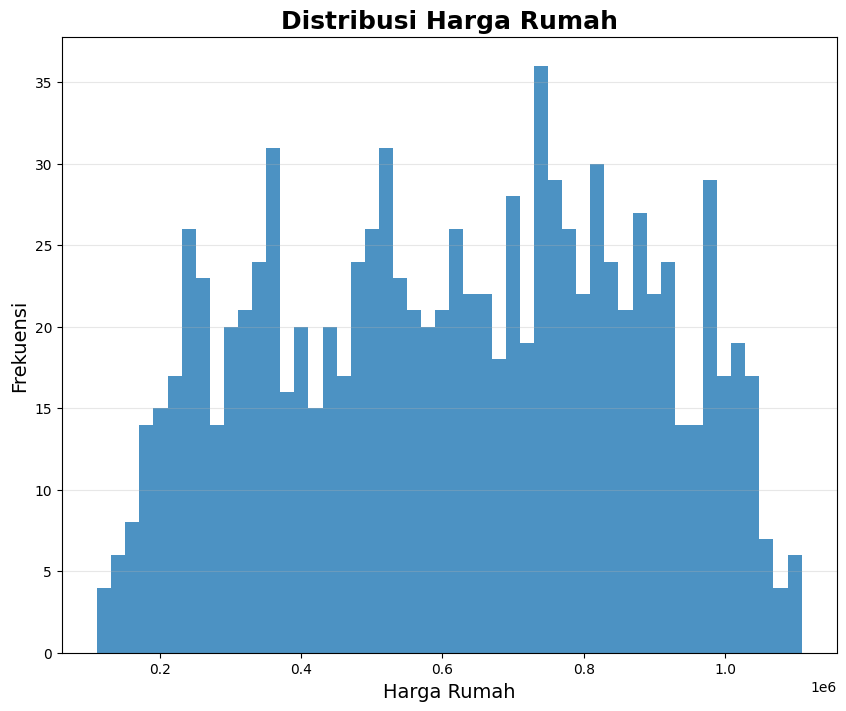

Target skewness: -0.06


In [8]:
plt.figure(figsize=(10, 8))
plt.hist(df['House_Price'], bins=50, alpha=0.8)
plt.title('Distribusi Harga Rumah', fontsize=18, fontweight='bold')
plt.xlabel('Harga Rumah', fontsize=14)
plt.ylabel('Frekuensi', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()

skew = df[TARGET_COL].skew()
print(f'Target skewness: {skew:.2f}')


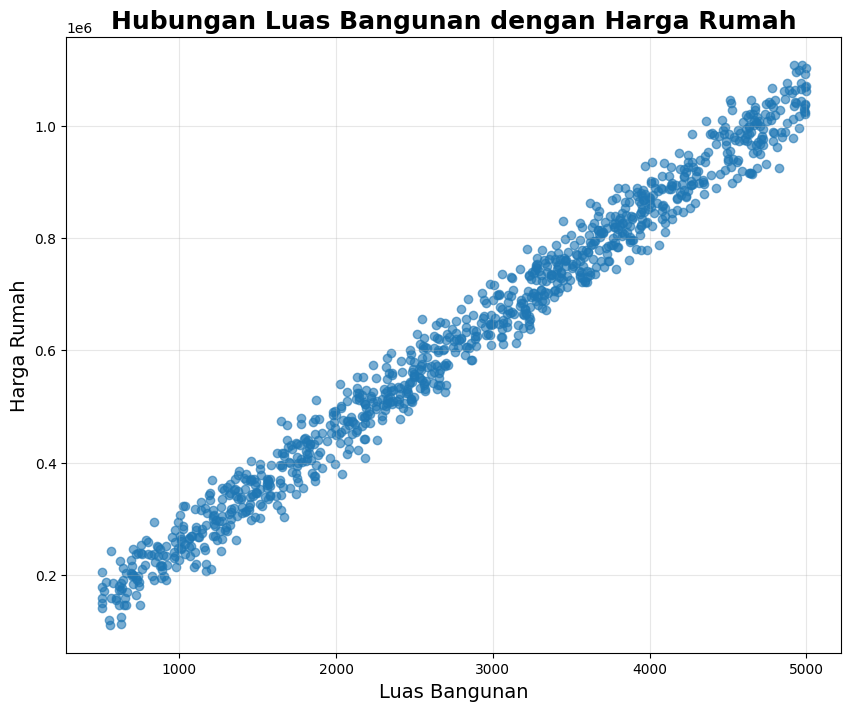

In [9]:
plt.figure(figsize=(10, 8))
plt.scatter(df['Square_Footage'], df['House_Price'], alpha=0.6)
plt.title('Hubungan Luas Bangunan dengan Harga Rumah', fontsize=18, fontweight='bold')
plt.xlabel('Luas Bangunan', fontsize=14)
plt.ylabel('Harga Rumah', fontsize=14)
plt.grid(alpha=0.3)
plt.show()


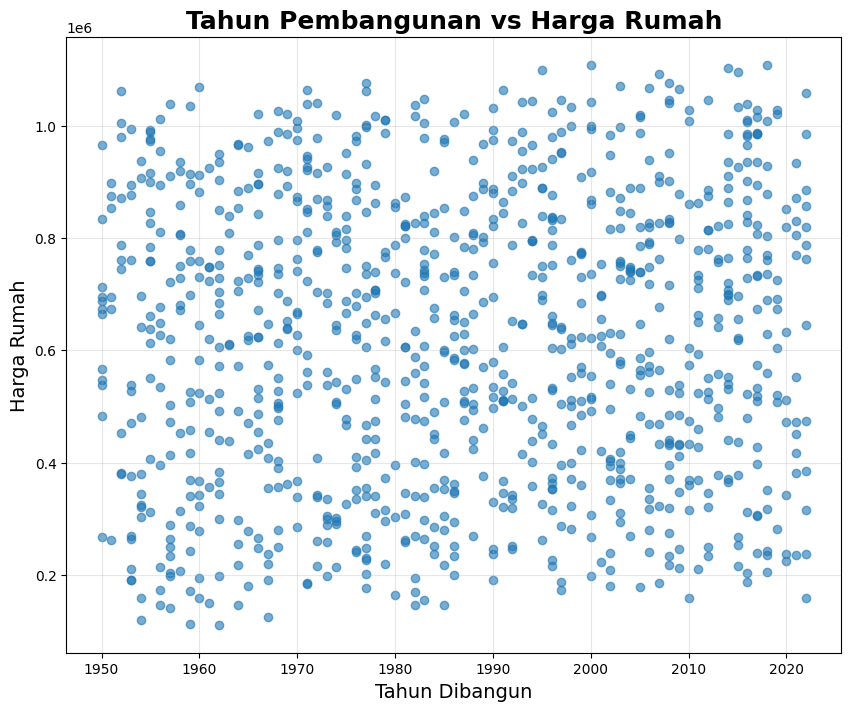

In [10]:
plt.figure(figsize=(10, 8))
plt.scatter(df['Year_Built'], df['House_Price'], alpha=0.6)
plt.title('Tahun Pembangunan vs Harga Rumah', fontsize=18, fontweight='bold')
plt.xlabel('Tahun Dibangun', fontsize=14)
plt.ylabel('Harga Rumah', fontsize=14)
plt.grid(alpha=0.3)
plt.show()


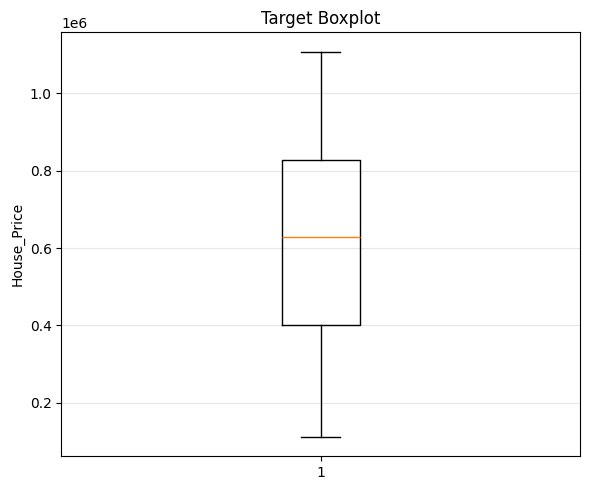

In [11]:
plt.figure(figsize=(6, 5))
plt.boxplot(df[TARGET_COL].dropna(), vert=True)
plt.title('Target Boxplot')
plt.ylabel(TARGET_COL)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 4.4 Analisis Distribusi Target (House_Price)

Visualisasi distribusi target dilakukan untuk memahami karakteristik sebaran harga rumah dalam dataset. Analisis ini penting untuk menentukan apakah diperlukan transformasi data sebelum pemodelan.

Hasil Analisis Histogram dan Boxplot:

1. Bentuk Distribusi: Distribusi harga rumah relatif merata dan mendekati distribusi normal. Tidak terdapat kecenderungan ekstrem ke kiri (left-skewed) atau ke kanan (right-skewed).

2. Skewness ≈ -0.06: Nilai skewness yang sangat mendekati 0 mengindikasikan distribusi yang hampir simetris sempurna. Dalam konteks statistik:
   - Skewness = 0: Distribusi simetris sempurna
   - Skewness antara -0.5 dan 0.5: Distribusi mendekati normal
   - Skewness > 1 atau < -1: Distribusi sangat miring

3. Tidak Ada Outlier: Boxplot menunjukkan bahwa seluruh data berada dalam rentang wajar (antara whisker). Tidak terdapat titik-titik di luar whisker yang mengindikasikan nilai ekstrem.

4. Median vs Mean: Median (\$628,267) sangat dekat dengan mean (\$618,861), konfirmasi tambahan bahwa distribusi mendekati normal.

Implikasi untuk Pemodelan:
- Tidak diperlukan transformasi logaritmik atau Box-Cox karena distribusi sudah normal
- Model dapat langsung dilatih dengan data asli
- Interpretasi hasil prediksi lebih mudah karena satuan tetap dalam USD


In [12]:
feature_cols = [c for c in df.columns if c != TARGET_COL]
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]

print(f'Total features: {len(feature_cols)}')
print(f'Numeric features: {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')


Total features: 7
Numeric features: 7
Categorical features: 0


,Feature,Abs_Correlation,Correlation
0,Square_Footage,0.991261,0.991261
1,Lot_Size,0.160412,0.160412
2,Garage_Size,0.052133,0.052133
3,Year_Built,0.051967,0.051967
4,Num_Bedrooms,0.014633,0.014633
5,Neighborhood_Quality,0.007770,-0.007770
6,Num_Bathrooms,0.001862,-0.001862


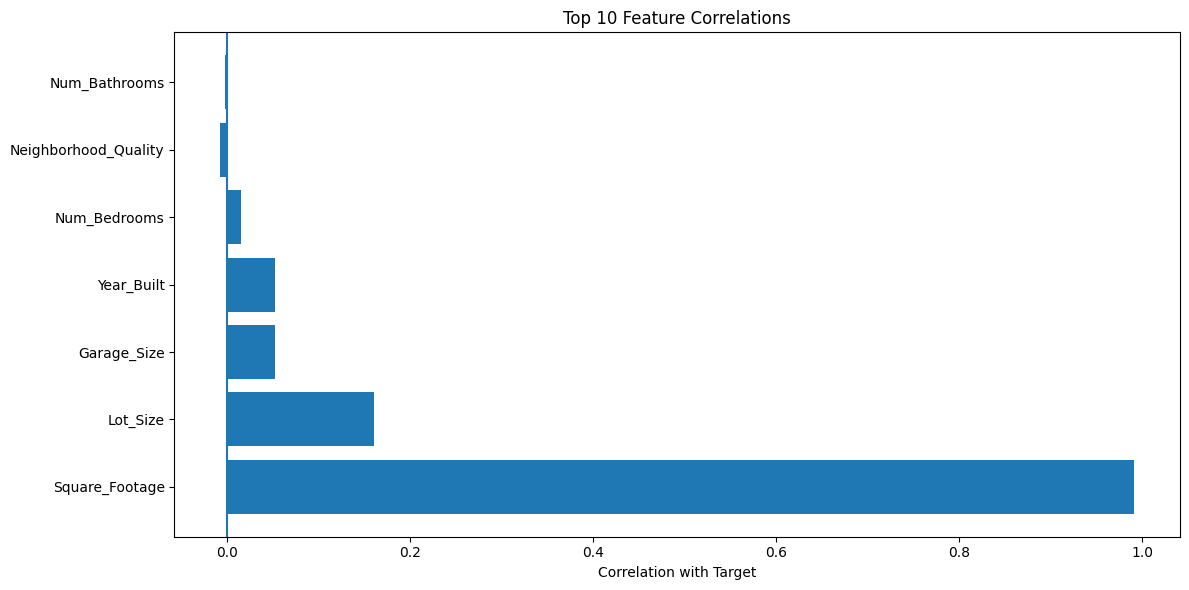

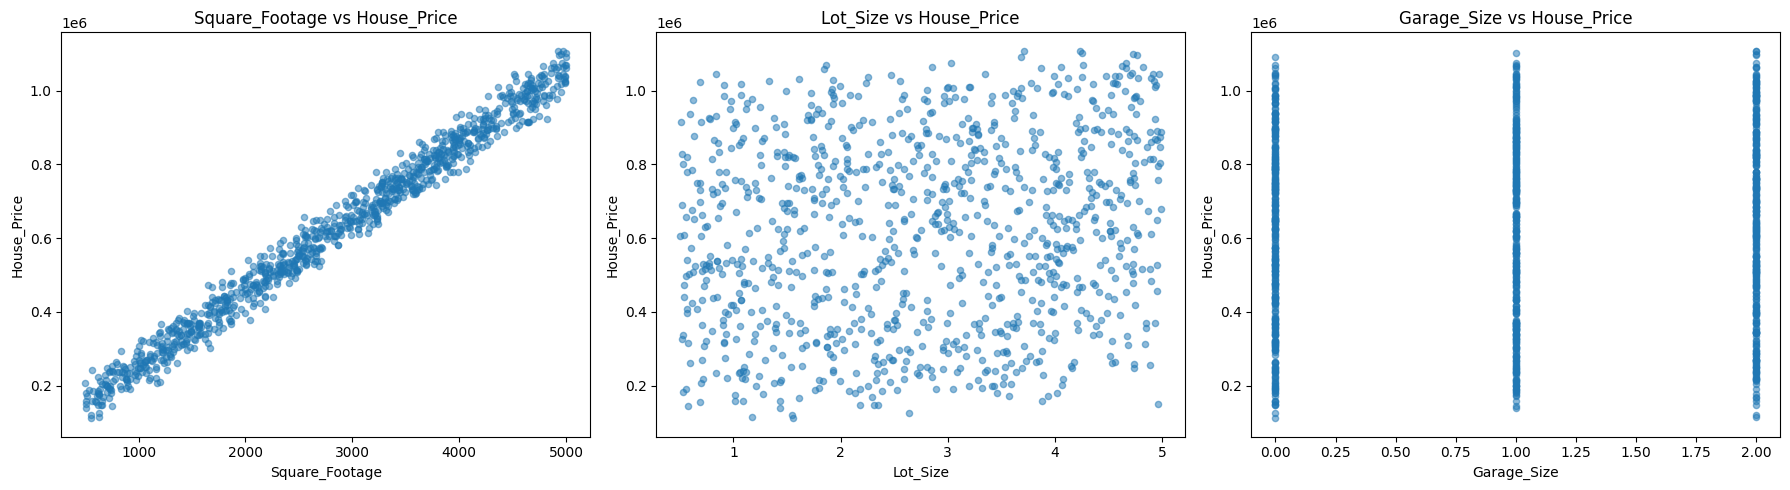

,Skewness
Square_Footage,-0.066001
Num_Bathrooms,0.049917
Lot_Size,-0.044288
Garage_Size,-0.040400
Num_Bedrooms,0.025884
Year_Built,-0.021254
Neighborhood_Quality,-0.020445


In [13]:
if len(num_cols) > 0:
    corr = df[num_cols + [TARGET_COL]].corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL)
    top_corr = corr.abs().sort_values(ascending=False).head(10)

    corr_df = pd.DataFrame({
        'Feature': top_corr.index,
        'Abs_Correlation': top_corr.values,
        'Correlation': corr[top_corr.index].values
    })
    display(corr_df)

    plt.figure(figsize=(12, 6))
    plt.barh(top_corr.index, corr[top_corr.index].values)
    plt.xlabel('Correlation with Target')
    plt.title('Top 10 Feature Correlations')
    plt.axvline(0)
    plt.tight_layout()
    plt.show()

    top3 = top_corr.index[:3]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, col in enumerate(top3):
        axes[i].scatter(df[col], df[TARGET_COL], alpha=0.5, s=20)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(TARGET_COL)
        axes[i].set_title(f'{col} vs {TARGET_COL}')
    plt.tight_layout()
    plt.show()

    skew_df = pd.DataFrame({'Skewness': df[num_cols].skew()})
    display(skew_df.sort_values(by='Skewness', key=abs, ascending=False).head(10))


if len(cat_cols) > 0:
    cat_card_df = pd.DataFrame({
        'Unique_Values': [df[col].nunique() for col in cat_cols]
    }, index=cat_cols)

    cat_card_df['Cardinality_Ratio'] = (cat_card_df['Unique_Values'] / len(df)) * 100
    display(cat_card_df.sort_values('Unique_Values', ascending=False).head(15))

    for col in cat_cols[:3]:
        display(df[col].value_counts().head(10).to_frame('Count'))

        if df[col].nunique() <= 10:
            df.boxplot(column=TARGET_COL, by=col, figsize=(10, 6))
            plt.suptitle('')
            plt.title(f'{TARGET_COL} by {col}')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()


### 4.5 Analisis Korelasi Fitur

Visualisasi matriks korelasi bertujuan untuk memetakan hubungan linear antar variabel dalam dataset. Melalui analisis ini, kita dapat mengidentifikasi fitur mana yang memiliki pengaruh paling kuat terhadap harga rumah.

Hasil Analisis Korelasi dengan Target (House_Price):

| Rank | Fitur | Korelasi | Kekuatan | Interpretasi |
|:----:|:------|:--------:|:---------|:-------------|
| 1 | Square_Footage | 0.991 | Sangat Kuat | Luas bangunan memiliki hubungan linear hampir sempurna dengan harga |
| 2 | Lot_Size | 0.160 | Lemah | Luas tanah memiliki pengaruh positif namun lemah |
| 3 | Garage_Size | 0.052 | Sangat Lemah | Ukuran garasi hampir tidak berpengaruh |
| 4 | Year_Built | 0.052 | Sangat Lemah | Tahun pembangunan hampir tidak berpengaruh |
| 5 | Num_Bedrooms | 0.015 | Negligible | Jumlah kamar tidur tidak berpengaruh signifikan |
| 6 | Neighborhood_Quality | -0.008 | Negligible | Kualitas lingkungan tidak berpengaruh signifikan |
| 7 | Num_Bathrooms | -0.002 | Negligible | Jumlah kamar mandi tidak berpengaruh signifikan |

Temuan Kunci:

Berdasarkan hasil analisis korelasi, terdapat satu fitur yang mendominasi yaitu `Square_Footage` dengan korelasi 0.991. Angka ini menunjukkan bahwa:
- Sekitar 99% variasi harga rumah dapat dijelaskan oleh luas bangunan saja
- Hubungan antara luas bangunan dan harga bersifat hampir perfectly linear
- Fitur-fitur lain memiliki kontribusi yang minimal (korelasi < 0.2)

Analisis Scatter Plot:
- Square_Footage vs House_Price: Titik-titik data membentuk garis lurus dengan sangat sedikit penyimpangan, mengkonfirmasi hubungan linear yang kuat
- Lot_Size vs House_Price: Pola tersebar acak tanpa tren yang jelas
- Garage_Size vs House_Price: Data tersebar dalam kolom vertikal (karena nilai diskrit 0, 1, 2) tanpa korelasi dengan harga

Implikasi untuk Pemodelan:

1. Linear Regression diharapkan sangat efektif karena hubungan utama bersifat linear
2. Feature selection oleh GA kemungkinan akan memilih Square_Footage sebagai fitur dominan
3. Model kompleks (Decision Tree, KNN) mungkin tidak memberikan keunggulan signifikan dibandingkan Linear Regression karena pola data yang sederhana
4. Fitur dengan korelasi mendekati 0 mungkin akan dibuang oleh GA karena tidak memberikan informasi tambahan yang berarti



# 5. PREPROCESSING DATA

## 5.1 Pemisahan Fitur dan Target

Pada tahap ini, dilakukan persiapan data untuk proses pelatihan model. Langkah pertama adalah memisahkan variabel independen (fitur) dari variabel dependen (target).

Pemisahan Data:
- X (Fitur): Semua kolom kecuali House_Price — digunakan sebagai input untuk prediksi
- y (Target): Kolom House_Price — nilai yang akan diprediksi oleh model

## 5.2 Pembagian Data (Train/Validation/Test Split)

Data dibagi menjadi 3 bagian dengan proporsi tertentu. Pembagian ini bertujuan untuk memastikan bahwa model yang dibangun dapat dievaluasi secara objektif dan tidak hanya bekerja baik pada data yang telah dilihat sebelumnya.

| Dataset | Proporsi | Jumlah | Fungsi |
|---------|:--------:|:------:|:-------|
| Training | 70% | 700 sampel | Digunakan untuk melatih model. Model mempelajari pola dari data ini. |
| Validation | 15% | 150 sampel | Digunakan untuk menghitung fitness GA. Membantu mencegah overfitting selama optimasi. |
| Test | 15% | 150 sampel | Digunakan untuk evaluasi akhir. Data ini tidak pernah dilihat selama training atau optimasi. |

Alasan Pembagian Tiga Bagian:

1. Data Training: Digunakan sebagai data pembelajaran untuk model. Pada KNN, data training menjadi referensi untuk menghitung jarak. Pada Decision Tree, digunakan untuk membangun struktur pohon. Pada Linear Regression, digunakan untuk menghitung koefisien.

2. Data Validation: Digunakan untuk menentukan parameter optimal melalui Genetic Algorithm. Dengan menggunakan data validation, pemilihan parameter dapat dilakukan tanpa melibatkan data testing sehingga evaluasi akhir tetap objektif. Penggunaan data validation membantu menghindari overfitting.

3. Data Testing: Digunakan pada tahap akhir untuk mengukur performa sebenarnya dari model. Data ini tidak dilibatkan dalam proses training maupun optimasi, sehingga hasil evaluasi mencerminkan kemampuan model pada data yang benar-benar baru.

Catatan:
- `random_state=42` digunakan untuk reproducibility (hasil dapat direproduksi)
- Tidak dilakukan scaling karena fitur sudah dalam skala yang relatif sebanding


In [14]:
# Memisahkan fitur (x) dan target (y)
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Split data : train(70%), validation(15%), test(15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED
)

X_train_enc = X_train
X_val_enc = X_val
X_test_enc = X_test

group_names = list(X.columns)
group_to_encoded_cols = {col: [col] for col in group_names}

print('=== DATA SPLIT ===')
print(f'Training set   : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Validation set : {X_val.shape[0]:,} samples ({X_val.shape[0]/len(df)*100:.1f}%)')
print(f'Test set       : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df)*100:.1f}%)')
print(f'\nJumlah fitur untuk GA: {len(group_names)}')
print(f'Fitur: {group_names}')


=== DATA SPLIT ===
Training set   : 700 samples (70.0%)
Validation set : 150 samples (15.0%)
Test set       : 150 samples (15.0%)

Jumlah fitur untuk GA: 7
Fitur: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']


# 6. IMPLEMENTASI GENETIC ALGORITHM

## 6.1 Konsep Genetic Algorithm

Genetic Algorithm (GA) adalah metode optimasi yang terinspirasi dari proses evolusi biologis. GA digunakan dalam penelitian ini untuk dua tujuan utama:

1. Feature Selection: Memilih subset fitur terbaik dari 7 fitur yang tersedia
2. Hyperparameter Tuning: Mencari kombinasi parameter optimal untuk setiap model

### Representasi Kromosom

Setiap individu (solusi kandidat) direpresentasikan sebagai array yang terdiri dari dua bagian:

```
Kromosom = [bit_1, bit_2, ..., bit_n, int_1, int_2, ...]
            ├────── Bit Mask ──────┤ ├── Integer Genes ──┤
            (Feature Selection)      (Hyperparameters)
```

Contoh untuk KNN (7 fitur):
```
[1, 0, 1, 1, 0, 1, 0,  |  7, 1, 2]
 ↑  ↑  ↑  ↑  ↑  ↑  ↑      ↑  ↑  ↑
 f1 f2 f3 f4 f5 f6 f7     k  w  p

Artinya:
- Fitur 1, 3, 4, 6 digunakan (bit=1)
- Fitur 2, 5, 7 tidak digunakan (bit=0)
- k = 7 neighbors
- w = 1 → weights='distance'
- p = 2 → Euclidean distance
```

### Komponen dan Operator GA

| Komponen | Metode | Parameter | Penjelasan Detail |
|----------|--------|-----------|-------------------|
| Inisialisasi | Random | prob=0.6 | Setiap bit punya 60% kemungkinan bernilai 1, sehingga rata-rata 60% fitur terpilih di awal |
| Fitness Function | RMSE Validation | - | Mengukur error prediksi pada validation set. Semakin kecil RMSE, semakin baik solusi |
| Seleksi | Tournament | k=3 | Pilih 3 individu random, ambil yang fitness terbaik sebagai parent |
| Crossover | Uniform | prob=0.8 | 80% kemungkinan crossover terjadi. Setiap gen punya 50% chance ditukar antara 2 parent |
| Mutasi Bit | Flip | prob=0.03 | 3% kemungkinan setiap bit di-flip (0→1 atau 1→0) |
| Mutasi Integer | Resample | prob=0.25 | 25% kemungkinan setiap integer gene di-random ulang dalam range valid |
| Elitisme | Top-N | N=1 | 1 individu terbaik langsung masuk ke generasi berikutnya tanpa modifikasi |

### Alur Proses Evolusi


1. Inisialisasi
*   Buat 30 individu dengan gen random
*   Setiap individu = kombinasi fitur + hyperparameter
2. Evaluasi Fitness Awal
*   Train model dengan konfigurasi dari setiap kromosom
*   Hitung RMSE pada validation set sebagai fitness
3. Loop Selama 15 Generasi:
*   Elitisme: Simpan 1 individu terbaik
*   Seleksi: Pilih parent dengan tournament selection
*   Crossover: Gabungkan gen dari 2 parent
*   Mutasi: Perubahan random untuk eksplorasi
*   Evaluasi: Hitung fitness generasi baru
*   Update Best: Simpan jika ada yang lebih baik
4. Return Solusi Terbaik
*   Kromosom dengan RMSE validation terendah


## 6.2 Parameter GA yang Digunakan

| Parameter | Nilai | Alasan Pemilihan |
|-----------|:-----:|------------------|
| `pop_size` | 30 | Cukup besar untuk menjaga diversity genetik, namun tidak terlalu besar sehingga komputasi tetap efisien |
| `n_gen` | 15 | Trade-off antara waktu konvergensi dan waktu komputasi. 15 generasi biasanya cukup untuk konvergensi |
| `tourn_k` | 3 | Selection pressure sedang. k=3 memberikan keseimbangan antara eksploitasi dan eksplorasi |
| `cx_prob` | 0.80 | Crossover rate tinggi untuk mendorong pertukaran informasi antar individu |
| `bit_mut_prob` | 0.03 | Mutasi rendah untuk feature selection agar tidak terlalu banyak fitur berubah |
| `int_mut_prob` | 0.25 | Lebih tinggi karena jumlah integer gene sedikit dan perlu eksplorasi lebih banyak |
| `elite` | 1 | Menjamin solusi terbaik tidak pernah hilang dari populasi |

## 6.3 Implementasi GA

Berikut adalah implementasi Genetic Algorithm yang dibuat dari nol tanpa menggunakan library eksternal:


In [15]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def decode_feature_mask(mask_bits, group_names, group_to_encoded_cols):
    selected_groups = [g for bit, g in zip(mask_bits, group_names) if int(bit) == 1]
    cols = []
    for g in selected_groups:
        cols.extend(group_to_encoded_cols.get(g, []))
    return selected_groups, list(dict.fromkeys(cols))


def _ensure_not_all_zero(bits):
    if bits.sum() == 0:
        bits[np.random.randint(0, len(bits))] = 1
    return bits


def init_population(pop_size, n_bits, int_genes):
    pop = []
    for _ in range(pop_size):
        bits = (np.random.rand(n_bits) < 0.6).astype(int)
        bits = _ensure_not_all_zero(bits)
        ints = [np.random.randint(lo, hi + 1) for lo, hi in int_genes]
        pop.append(np.concatenate([bits, ints]))
    return np.array(pop, dtype=int)


def tournament_select(pop, fitness, k=3):
    idxs = np.random.randint(0, len(pop), size=k)
    best = idxs[np.argmin(fitness[idxs])]
    return pop[best].copy()


def uniform_crossover(p1, p2):
    mask = np.random.rand(len(p1)) < 0.5
    c1, c2 = p1.copy(), p2.copy()
    c1[mask] = p2[mask]
    c2[mask] = p1[mask]
    return c1, c2


def mutate(ch, n_bits, int_genes, bit_mut_prob=0.03, int_mut_prob=0.25):
    ch = ch.copy()

    for i in range(n_bits):
        if np.random.rand() < bit_mut_prob:
            ch[i] = 1 - ch[i]
    ch[:n_bits] = _ensure_not_all_zero(ch[:n_bits])

    offset = n_bits
    for j, (lo, hi) in enumerate(int_genes):
        if np.random.rand() < int_mut_prob:
            ch[offset + j] = np.random.randint(lo, hi + 1)

    return ch


def run_ga(
    eval_fn,
    n_bits,
    int_genes,
    pop_size=30,
    n_gen=15,
    tourn_k=3,
    cx_prob=0.80,
    bit_mut_prob=0.03,
    int_mut_prob=0.25,
    elite=1,
    verbose=True,
):
    pop = init_population(pop_size, n_bits, int_genes)
    fitness = np.array([eval_fn(ch) for ch in pop])

    best_idx = np.argmin(fitness)
    best_fit = fitness[best_idx]
    best_ch = pop[best_idx].copy()

    if verbose:
        print(f'Gen 0 | Best RMSE: {best_fit:.2f}')

    for gen in range(1, n_gen + 1):
        elite_idxs = np.argsort(fitness)[:elite]
        new_pop = [pop[i].copy() for i in elite_idxs]

        while len(new_pop) < pop_size:
            p1 = tournament_select(pop, fitness, tourn_k)
            p2 = tournament_select(pop, fitness, tourn_k)

            if np.random.rand() < cx_prob:
                c1, c2 = uniform_crossover(p1, p2)
            else:
                c1, c2 = p1.copy(), p2.copy()

            new_pop.append(mutate(c1, n_bits, int_genes, bit_mut_prob, int_mut_prob))
            if len(new_pop) < pop_size:
                new_pop.append(mutate(c2, n_bits, int_genes, bit_mut_prob, int_mut_prob))

        pop = np.array(new_pop, dtype=int)
        fitness = np.array([eval_fn(ch) for ch in pop])

        gen_best_idx = np.argmin(fitness)
        gen_best_fit = fitness[gen_best_idx]

        if gen_best_fit < best_fit:
            best_fit = gen_best_fit
            best_ch = pop[gen_best_idx].copy()

        if verbose:
            print(f'Gen {gen} | Best RMSE: {best_fit:.2f}')

    return best_ch, best_fit


# 7. IMPLEMENTASI MODEL

## 7.1 Model 1: K-Nearest Neighbors (KNN) + GA

### Konfigurasi KNN untuk Optimasi GA

Pada model KNN, GA akan mengoptimasi feature selection dan 3 hyperparameter berikut:

| Parameter | Range | Penjelasan |
|-----------|:-----:|------------|
| n_neighbors (k) | 1-50 | Jumlah tetangga terdekat. k kecil → model sensitif, k besar → model lebih smooth |
| weights | 0 atau 1 | 0='uniform' (semua tetangga sama penting), 1='distance' (tetangga dekat lebih berpengaruh) |
| p | 1 atau 2 | Metrik jarak. 1=Manhattan, 2=Euclidean |

Kode berikut menjalankan GA untuk menemukan kombinasi optimal:


In [16]:
n_bits = len(group_names)

int_genes_knn = [
    (1, 50),
    (0, 1),
    (1, 2),
]

def eval_knn(chrom):
    bits = chrom[:n_bits].astype(int)
    k, w, p = chrom[n_bits:].astype(int)

    if bits.sum() == 0:
        return 1e9

    _, cols = decode_feature_mask(bits, group_names, group_to_encoded_cols)
    if len(cols) == 0:
        return 1e9

    weights = 'distance' if w == 1 else 'uniform'
    model = KNeighborsRegressor(n_neighbors=int(k), weights=weights, p=int(p))
    model.fit(X_train_enc[cols], y_train)
    pred = model.predict(X_val_enc[cols])
    return rmse(y_val, pred)


best_knn_ch, best_knn_rmse = run_ga(
    eval_fn=eval_knn,
    n_bits=n_bits,
    int_genes=int_genes_knn,
    pop_size=30,
    n_gen=15,
    cx_prob=0.8,
    bit_mut_prob=0.03,
    int_mut_prob=0.25,
    verbose=True,
)

bits = best_knn_ch[:n_bits].astype(int)
k, w, p = best_knn_ch[n_bits:].astype(int)

selected_groups, selected_cols = decode_feature_mask(
    bits, group_names, group_to_encoded_cols
)

weights = 'distance' if w == 1 else 'uniform'

print('\nBest KNN configuration')
print('Selected features:', len(selected_groups))
print('k:', int(k), 'weights:', weights, 'p:', int(p))


knn_best = KNeighborsRegressor(n_neighbors=int(k), weights=weights, p=int(p))
knn_best.fit(X_train_enc[selected_cols], y_train)

knn_train_pred = knn_best.predict(X_train_enc[selected_cols])
knn_val_pred = knn_best.predict(X_val_enc[selected_cols])

from sklearn.metrics import mean_absolute_error, r2_score

knn_train_rmse = rmse(y_train, knn_train_pred)
knn_train_mae = mean_absolute_error(y_train, knn_train_pred)
knn_train_r2 = r2_score(y_train, knn_train_pred)

knn_val_rmse = rmse(y_val, knn_val_pred)
knn_val_mae = mean_absolute_error(y_val, knn_val_pred)
knn_val_r2 = r2_score(y_val, knn_val_pred)

print('\nTrain metrics')
print(f'RMSE: {knn_train_rmse:.2f}')
print(f'MAE : {knn_train_mae:.2f}')
print(f'R2  : {knn_train_r2:.4f}')

print('\nValidation metrics')
print(f'RMSE: {knn_val_rmse:.2f}')
print(f'MAE : {knn_val_mae:.2f}')
print(f'R2  : {knn_val_r2:.4f}')


X_trainval = pd.concat([X_train_enc, X_val_enc])
y_trainval = pd.concat([y_train, y_val])

knn_final = KNeighborsRegressor(n_neighbors=int(k), weights=weights, p=int(p))
knn_final.fit(X_trainval[selected_cols], y_trainval)

knn_test_pred = knn_final.predict(X_test_enc[selected_cols])

knn_test_rmse = rmse(y_test, knn_test_pred)
knn_test_mae = mean_absolute_error(y_test, knn_test_pred)
knn_test_r2 = r2_score(y_test, knn_test_pred)

print('\nTest metrics')
print(f'RMSE: {knn_test_rmse:.2f}')
print(f'MAE : {knn_test_mae:.2f}')
print(f'R2  : {knn_test_r2:.4f}')


Gen 0 | Best RMSE: 31174.29
Gen 1 | Best RMSE: 30988.70
Gen 2 | Best RMSE: 30805.64
Gen 3 | Best RMSE: 30652.16
Gen 4 | Best RMSE: 30125.86
Gen 5 | Best RMSE: 29963.58
Gen 6 | Best RMSE: 29963.58
Gen 7 | Best RMSE: 29963.58
Gen 8 | Best RMSE: 29963.58
Gen 9 | Best RMSE: 29717.00
Gen 10 | Best RMSE: 29717.00
Gen 11 | Best RMSE: 29717.00
Gen 12 | Best RMSE: 29717.00
Gen 13 | Best RMSE: 29717.00
Gen 14 | Best RMSE: 29717.00
Gen 15 | Best RMSE: 29717.00

Best KNN configuration
Selected features: 6
k: 8 weights: distance p: 1

Train metrics
RMSE: 0.00
MAE : 0.00
R2  : 1.0000

Validation metrics
RMSE: 29717.00
MAE : 24237.54
R2  : 0.9843

Test metrics
RMSE: 29995.03
MAE : 24683.54
R2  : 0.9874


### Interpretasi Hasil KNN + GA

Berdasarkan hasil eksekusi Genetic Algorithm di atas, diperoleh parameter optimal untuk model KNN.

Parameter Optimal yang Ditemukan:
- GA secara otomatis memilih fitur-fitur yang paling relevan
- Nilai k, weights, dan p optimal ditentukan berdasarkan RMSE validation terendah

NOTE: Fenomena Train RMSE = 0

Jika hasil menunjukkan Train RMSE = 0 dan Train R² = 1.0, ini adalah perilaku normal untuk KNN dengan `weights='distance'`, bukan error atau bug.

Penjelasan Fenomena:

Ketika KNN dengan `weights='distance'` memprediksi data yang sudah ada di training set:

1. Titik tersebut menjadi tetangga terdekat dirinya sendiri dengan jarak = 0
2. Dengan pembobotan distance, bobot dihitung sebagai 1/jarak = 1/0 = ∞ (infinite)
3. Bobot infinite membuat prediksi 100% ditentukan oleh titik itu sendiri
4. Akibatnya, prediksi selalu sama persis dengan nilai asli → error = 0


Kesimpulan:
- Validation RMSE: Valid dan digunakan untuk fitness GA
- Test RMSE: Valid untuk evaluasi performa sebenarnya
- Train RMSE: Tidak bermakna untuk KNN dengan distance weighting, sebaiknya diabaikan

Metrik yang harus diperhatikan untuk menilai performa KNN adalah Validation dan Test metrics.


## 7.2 Model 2: Decision Tree + GA

### Konfigurasi Decision Tree untuk Optimasi GA

Pada model Decision Tree, GA akan mengoptimasi feature selection dan 4 hyperparameter berikut:

| Parameter | Range | Penjelasan |
|-----------|:-----:|------------|
| max_depth | 0-30 | Kedalaman maksimum pohon. 0=unlimited. Terlalu dalam → overfitting |
| min_samples_split | 2-20 | Minimum sampel untuk melakukan split. Lebih besar → pohon lebih sederhana |
| min_samples_leaf | 1-10 | Minimum sampel di leaf node. Lebih besar → mencegah overfitting |
| criterion | 0 atau 1 | 0='squared_error', 1='absolute_error' |

Kode berikut menjalankan GA untuk menemukan kombinasi optimal:


In [17]:
int_genes_dt = [
    (0, 30),
    (2, 20),
    (1, 10),
    (0, 1),
]

def eval_dt(chrom):
    # Memisahkan bagian seleksi fitur dan parameter model
    bits = chrom[:n_bits].astype(int)
    max_depth, mss, msl, crit = chrom[n_bits:].astype(int)

    # Jika tidak ada fitur yang dipilih, beri penalti
    if bits.sum() == 0:
        return 1e9

    # Ambil kolom berdasarkan bit mask
    _, cols = decode_feature_mask(bits, group_names, group_to_encoded_cols)
    if len(cols) == 0:
        return 1e9

    # Konversi parameter GA ke format Decision Tree
    depth = None if max_depth == 0 else int(max_depth)
    criterion = 'absolute_error' if crit == 1 else 'squared_error'

    # Latih model pada data training
    model = DecisionTreeRegressor(
        random_state=RANDOM_SEED,
        max_depth=depth,
        min_samples_split=int(mss),
        min_samples_leaf=int(msl),
        criterion=criterion,
    )
    model.fit(X_train_enc[cols], y_train)

    # Evaluasi menggunakan data validasi
    pred = model.predict(X_val_enc[cols])
    return rmse(y_val, pred)


# Menjalankan GA untuk mencari konfigurasi terbaik
best_dt_ch, best_dt_rmse = run_ga(
    eval_fn=eval_dt,
    n_bits=n_bits,
    int_genes=int_genes_dt,
    pop_size=30,
    n_gen=15,
    cx_prob=0.8,
    bit_mut_prob=0.03,
    int_mut_prob=0.25,
    verbose=True,
)

# Ekstraksi hasil terbaik
bits = best_dt_ch[:n_bits].astype(int)
max_depth, mss, msl, crit = best_dt_ch[n_bits:].astype(int)

selected_groups, selected_cols = decode_feature_mask(
    bits, group_names, group_to_encoded_cols
)

depth = None if max_depth == 0 else int(max_depth)
criterion = 'absolute_error' if crit == 1 else 'squared_error'

print('\nBest Decision Tree configuration')
print('Number of selected features:', len(selected_groups))
print(
    'max_depth:', depth,
    '\nmin_samples_split:', int(mss),
    '\nmin_samples_leaf:', int(msl),
    '\ncriterion:', criterion
)

# Melatih model terbaik pada data training
dt_best = DecisionTreeRegressor(
    random_state=RANDOM_SEED,
    max_depth=depth,
    min_samples_split=int(mss),
    min_samples_leaf=int(msl),
    criterion=criterion,
)
dt_best.fit(X_train_enc[selected_cols], y_train)

# Prediksi data training dan validasi
dt_train_pred = dt_best.predict(X_train_enc[selected_cols])
dt_val_pred = dt_best.predict(X_val_enc[selected_cols])

# Evaluasi performa
dt_train_rmse = rmse(y_train, dt_train_pred)
dt_train_mae = mean_absolute_error(y_train, dt_train_pred)
dt_train_r2 = r2_score(y_train, dt_train_pred)

dt_val_rmse = rmse(y_val, dt_val_pred)
dt_val_mae = mean_absolute_error(y_val, dt_val_pred)
dt_val_r2 = r2_score(y_val, dt_val_pred)

print('\nTraining results')
print(f'RMSE: {dt_train_rmse:.2f}')
print(f'MAE : {dt_train_mae:.2f}')
print(f'R2  : {dt_train_r2:.4f}')

print('\nValidation results')
print(f'RMSE: {dt_val_rmse:.2f}')
print(f'MAE : {dt_val_mae:.2f}')
print(f'R2  : {dt_val_r2:.4f}')

# Pelatihan ulang menggunakan data train + validation
X_trainval = pd.concat([X_train_enc, X_val_enc])
y_trainval = pd.concat([y_train, y_val])

dt_final = DecisionTreeRegressor(
    random_state=RANDOM_SEED,
    max_depth=depth,
    min_samples_split=int(mss),
    min_samples_leaf=int(msl),
    criterion=criterion,
)
dt_final.fit(X_trainval[selected_cols], y_trainval)

# Evaluasi pada data test
dt_test_pred = dt_final.predict(X_test_enc[selected_cols])

dt_test_rmse = rmse(y_test, dt_test_pred)
dt_test_mae = mean_absolute_error(y_test, dt_test_pred)
dt_test_r2 = r2_score(y_test, dt_test_pred)

print('\nTest results')
print(f'RMSE: {dt_test_rmse:.2f}')
print(f'MAE : {dt_test_mae:.2f}')
print(f'R2  : {dt_test_r2:.4f}')


Gen 0 | Best RMSE: 31211.04
Gen 1 | Best RMSE: 31211.04
Gen 2 | Best RMSE: 29833.81
Gen 3 | Best RMSE: 29179.10
Gen 4 | Best RMSE: 29179.10
Gen 5 | Best RMSE: 29179.10
Gen 6 | Best RMSE: 29179.10
Gen 7 | Best RMSE: 29179.10
Gen 8 | Best RMSE: 28886.27
Gen 9 | Best RMSE: 28886.27
Gen 10 | Best RMSE: 28886.27
Gen 11 | Best RMSE: 28886.27
Gen 12 | Best RMSE: 28886.27
Gen 13 | Best RMSE: 28787.93
Gen 14 | Best RMSE: 28787.93
Gen 15 | Best RMSE: 28787.93

Best Decision Tree configuration
Number of selected features: 7
max_depth: 20 
min_samples_split: 5 
min_samples_leaf: 7 
criterion: squared_error

Training results
RMSE: 20605.65
MAE : 16101.53
R2  : 0.9934

Validation results
RMSE: 28787.93
MAE : 23157.92
R2  : 0.9853

Test results
RMSE: 27181.09
MAE : 21682.59
R2  : 0.9897


### Interpretasi Hasil Decision Tree + GA

Berdasarkan hasil eksekusi GA, diperoleh parameter optimal untuk model Decision Tree.

Analisis Hyperparameter:

1. max_depth: Kedalaman pohon yang optimal menunjukkan seberapa kompleks aturan keputusan yang diperlukan. Jika max_depth rendah, berarti pola dalam data cukup sederhana.

2. min_samples_split & min_samples_leaf: Nilai yang lebih tinggi menghasilkan pohon yang lebih sederhana dan lebih resistant terhadap overfitting.

3. criterion: Pilihan antara squared_error (default) atau absolute_error bergantung pada sensitivitas terhadap outlier yang diinginkan.

Karakteristik Decision Tree:
- Dapat menangkap hubungan non-linear
- Mudah diinterpretasi (dapat divisualisasi sebagai pohon)
- Rentan overfitting jika tidak dikontrol dengan baik



## 7.3 Model 3: Linear Regression + GA

### Konfigurasi Linear Regression untuk Optimasi GA

Linear Regression adalah model paling sederhana yang digunakan dalam penelitian ini. Karena tidak memiliki hyperparameter kompleks, GA hanya digunakan untuk feature selection.

Karakteristik Linear Regression:
- Mengasumsikan hubungan linear antara fitur dan target
- Tidak memiliki hyperparameter untuk di-tune (kecuali regularization yang tidak digunakan di sini)
- Cepat dalam training dan prediksi
- Mudah diinterpretasi melalui koefisien

Kode berikut menjalankan GA untuk memilih fitur optimal:


In [18]:
int_genes_lr = []
def eval_lr(chrom):
    # Ambil bit seleksi fitur
    bits = chrom[:n_bits].astype(int)

    # Kondisi tidak valid jika tidak ada fitur terpilih
    if bits.sum() == 0:
        return 1e9

    # Tentukan kolom yang digunakan
    _, cols = decode_feature_mask(bits, group_names, group_to_encoded_cols)
    if len(cols) == 0:
        return 1e9

    # Latih model Linear Regression
    model = LinearRegression()
    model.fit(X_train_enc[cols], y_train)

    # Evaluasi pada data validasi
    pred = model.predict(X_val_enc[cols])
    return rmse(y_val, pred)


# Proses optimasi menggunakan Genetic Algorithm
best_lr_ch, best_lr_rmse = run_ga(
    eval_fn=eval_lr,
    n_bits=n_bits,
    int_genes=int_genes_lr,
    pop_size=30,
    n_gen=15,
    cx_prob=0.8,
    bit_mut_prob=0.03,
    int_mut_prob=0.0,
    verbose=True,
)

# Ekstraksi fitur terbaik
bits = best_lr_ch[:n_bits].astype(int)
selected_groups, selected_cols = decode_feature_mask(
    bits, group_names, group_to_encoded_cols
)

print('\nBest Linear Regression configuration')
print('Number of selected features:', len(selected_groups))


# Pelatihan model menggunakan fitur terpilih
lr_best = LinearRegression()
lr_best.fit(X_train_enc[selected_cols], y_train)

# Prediksi data training dan validasi
lr_train_pred = lr_best.predict(X_train_enc[selected_cols])
lr_val_pred = lr_best.predict(X_val_enc[selected_cols])

# Evaluasi performa
lr_train_rmse = rmse(y_train, lr_train_pred)
lr_train_mae = mean_absolute_error(y_train, lr_train_pred)
lr_train_r2 = r2_score(y_train, lr_train_pred)

lr_val_rmse = rmse(y_val, lr_val_pred)
lr_val_mae = mean_absolute_error(y_val, lr_val_pred)
lr_val_r2 = r2_score(y_val, lr_val_pred)

print('\nTraining results')
print(f'RMSE: {lr_train_rmse:.2f}')
print(f'MAE : {lr_train_mae:.2f}')
print(f'R2  : {lr_train_r2:.4f}')

print('\nValidation results')
print(f'RMSE: {lr_val_rmse:.2f}')
print(f'MAE : {lr_val_mae:.2f}')
print(f'R2  : {lr_val_r2:.4f}')


# Pelatihan ulang menggunakan gabungan data training dan validasi
X_trainval = pd.concat([X_train_enc, X_val_enc])
y_trainval = pd.concat([y_train, y_val])

lr_final = LinearRegression()
lr_final.fit(X_trainval[selected_cols], y_trainval)

# Evaluasi pada data test
lr_test_pred = lr_final.predict(X_test_enc[selected_cols])

lr_test_rmse = rmse(y_test, lr_test_pred)
lr_test_mae = mean_absolute_error(y_test, lr_test_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)

print('\nTest results')
print(f'RMSE: {lr_test_rmse:.2f}')
print(f'MAE : {lr_test_mae:.2f}')
print(f'R2  : {lr_test_r2:.4f}')


Gen 0 | Best RMSE: 10263.78
Gen 1 | Best RMSE: 10263.78
Gen 2 | Best RMSE: 10263.78
Gen 3 | Best RMSE: 10263.78
Gen 4 | Best RMSE: 10263.78
Gen 5 | Best RMSE: 10263.78
Gen 6 | Best RMSE: 10263.78
Gen 7 | Best RMSE: 10263.78
Gen 8 | Best RMSE: 10263.78
Gen 9 | Best RMSE: 10263.78
Gen 10 | Best RMSE: 10263.78
Gen 11 | Best RMSE: 10263.78
Gen 12 | Best RMSE: 10263.78
Gen 13 | Best RMSE: 10263.78
Gen 14 | Best RMSE: 10263.78
Gen 15 | Best RMSE: 10263.78

Best Linear Regression configuration
Number of selected features: 7

Training results
RMSE: 9631.79
MAE : 7614.59
R2  : 0.9986

Validation results
RMSE: 10263.78
MAE : 8235.04
R2  : 0.9981

Test results
RMSE: 9959.97
MAE : 7930.03
R2  : 0.9986


### Interpretasi Hasil Linear Regression + GA

Berdasarkan hasil EDA sebelumnya, variabel `Square_Footage` memiliki korelasi 0.991 dengan House_Price. Ini menunjukkan hubungan yang hampir perfectly linear antara luas bangunan dan harga rumah.

Mengapa Linear Regression Diharapkan Sangat Baik?

1. Asumsi Linearitas Terpenuhi: Scatter plot Square_Footage vs House_Price membentuk garis lurus dengan sangat sedikit penyimpangan.

2. Kesederhanaan adalah Kelebihan: Dalam kasus dimana hubungan memang linear, model yang lebih kompleks tidak akan memberikan keuntungan dan malah berisiko overfitting.

3. Feature Selection Efektif: GA kemungkinan akan memilih Square_Footage sebagai fitur utama (atau bahkan satu-satunya) karena fitur lain tidak berkontribusi signifikan.

Formula Prediksi:
```
House_Price = β₀ + β₁×Square_Footage + β₂×Fitur₂ + ... + βₙ×Fiturₙ
```



# 8. HASIL DAN ANALISIS

## 8.1 Metrik Evaluasi

Tahap terakhir dalam alur penelitian ini adalah Evaluasi Performa Model. Setelah model final terbentuk dengan parameter optimal dari GA, dilakukan pengujian menyeluruh untuk mengukur kemampuan generalisasi model.

Metrik yang Digunakan:

| Metrik | Formula | Interpretasi | Semakin Baik Jika |
|--------|---------|--------------|-------------------|
| RMSE | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Root Mean Squared Error - error dalam satuan asli (USD) | Semakin kecil |
| MAE | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Mean Absolute Error - rata-rata error absolut | Semakin kecil |
| R² | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proporsi variansi yang dijelaskan oleh model (0-1) | Mendekati 1 |
| MAPE | $\frac{100}{n}\sum|\frac{y_i - \hat{y}_i}{y_i}|$ | Mean Absolute Percentage Error - error dalam % | Semakin kecil |

Interpretasi Metrik:

1. RMSE (Root Mean Squared Error):
   - Memberikan penalti lebih besar untuk error yang besar
   - Dalam satuan yang sama dengan target (USD)
   - RMSE = $10,000 (berarti rata-rata error prediksi sekitar 10.000 dollar)

2. MAE (Mean Absolute Error):
   - Lebih robust terhadap outlier dibanding RMSE
   - Interpretasi langsung: rata-rata kesalahan prediksi

3. R² (Coefficient of Determination):
   - R² = 1.0: Model menjelaskan 100% variasi data (perfect)
   - R² = 0.9: Model menjelaskan 90% variasi data (sangat baik)
   - R² = 0.0: Model tidak lebih baik dari prediksi menggunakan mean

4. MAPE (Mean Absolute Percentage Error):
   - Mudah dikomunikasikan: "Model memprediksi dengan error rata-rata X%"
   - MAPE < 10% umumnya dianggap akurat

Blok kode berikut menghitung metrik evaluasi pada tiga subset data:


## 8.2

In [19]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Hitung MAPE pada data test
knn_test_mape = mape(y_test, knn_test_pred)
dt_test_mape = mape(y_test, dt_test_pred)
lr_test_mape = mape(y_test, lr_test_pred)


# Tabel perbandingan performa model
results = pd.DataFrame([
    {
        'Model': 'KNN + GA',
        'Train_RMSE': knn_train_rmse,
        'Train_MAE': knn_train_mae,
        'Train_R2': knn_train_r2,
        'Val_RMSE': knn_val_rmse,
        'Val_MAE': knn_val_mae,
        'Val_R2': knn_val_r2,
        'Test_RMSE': knn_test_rmse,
        'Test_MAE': knn_test_mae,
        'Test_MAPE (%)': knn_test_mape,
        'Test_R2': knn_test_r2,
    },
    {
        'Model': 'Decision Tree + GA',
        'Train_RMSE': dt_train_rmse,
        'Train_MAE': dt_train_mae,
        'Train_R2': dt_train_r2,
        'Val_RMSE': dt_val_rmse,
        'Val_MAE': dt_val_mae,
        'Val_R2': dt_val_r2,
        'Test_RMSE': dt_test_rmse,
        'Test_MAE': dt_test_mae,
        'Test_MAPE (%)': dt_test_mape,
        'Test_R2': dt_test_r2,
    },
    {
        'Model': 'Linear Regression + GA',
        'Train_RMSE': lr_train_rmse,
        'Train_MAE': lr_train_mae,
        'Train_R2': lr_train_r2,
        'Val_RMSE': lr_val_rmse,
        'Val_MAE': lr_val_mae,
        'Val_R2': lr_val_r2,
        'Test_RMSE': lr_test_rmse,
        'Test_MAE': lr_test_mae,
        'Test_MAPE (%)': lr_test_mape,
        'Test_R2': lr_test_r2,
    },
]).sort_values('Test_RMSE')

print('Model performance comparison')
display(results)

print('\nOverfitting Analisis')
for _, row in results.iterrows():
    model_name = row['Model']
    train_rmse_val = row['Train_RMSE']
    val_rmse_val = row['Val_RMSE']
    test_rmse_val = row['Test_RMSE']

    selisih = train_rmse_val - val_rmse_val

    print(f"\n{model_name}")
    print(f"Train RMSE : {train_rmse_val:,.2f}")
    print(f"Val RMSE   : {val_rmse_val:,.2f}")
    print(f"Test RMSE  : {test_rmse_val:,.2f}")

    if train_rmse_val < val_rmse_val - 5000:
        print(f"Indikasi: overfitting (selisih {selisih:,.2f})")
    elif abs(selisih) < 2000:
        print(f"Indikasi: model stabil (selisih {selisih:,.2f})")
    else:
        print(f"Selisih Train–Validation: {selisih:,.2f}")


Model performance comparison


,Model,Train_RMSE,Train_MAE,Train_R2,Val_RMSE,Val_MAE,Val_R2,Test_RMSE,Test_MAE,Test_MAPE (%),Test_R2
2,Linear Regression + GA,9631.785553,7614.585671,0.998559,10263.779912,8235.042479,0.998127,9959.968976,7930.027717,1.693739,0.998611
1,Decision Tree + GA,20605.651904,16101.532216,0.993407,28787.931471,23157.915481,0.985268,27181.086283,21682.591985,4.552229,0.989657
0,KNN + GA,0.000000,0.000000,1.000000,29717.002365,24237.540297,0.984302,29995.030932,24683.540660,5.074004,0.987404



Overfitting Analisis

Linear Regression + GA
Train RMSE : 9,631.79
Val RMSE   : 10,263.78
Test RMSE  : 9,959.97
Indikasi: model stabil (selisih -631.99)

Decision Tree + GA
Train RMSE : 20,605.65
Val RMSE   : 28,787.93
Test RMSE  : 27,181.09
Indikasi: overfitting (selisih -8,182.28)

KNN + GA
Train RMSE : 0.00
Val RMSE   : 29,717.00
Test RMSE  : 29,995.03
Indikasi: overfitting (selisih -29,717.00)


## 8.3 Visualisasi Perbandingan Model

Visualisasi berikut bertujuan untuk mempermudah interpretasi hasil perbandingan model secara grafis. Melalui visualisasi, perbedaan performa antar model dapat terlihat dengan lebih jelas dan intuitif.


In [20]:
models = ['Linear Regression\n+ GA', 'Decision Tree\n+ GA', 'KNN\n+ GA']

# Use the already calculated values from your comparison table
train_rmse = [lr_train_rmse, dt_train_rmse, knn_train_rmse]
val_rmse = [lr_val_rmse, dt_val_rmse, knn_val_rmse]
test_rmse = [lr_test_rmse, dt_test_rmse, knn_test_rmse]

train_mae = [lr_train_mae, dt_train_mae, knn_train_mae]
val_mae = [lr_val_mae, dt_val_mae, knn_val_mae]
test_mae = [sklearn_mae(y_test, lr_test_pred),
            sklearn_mae(y_test, dt_test_pred),
            sklearn_mae(y_test, knn_test_pred)]

train_r2 = [lr_train_r2, dt_train_r2, knn_train_r2]
val_r2 = [lr_val_r2, dt_val_r2, knn_val_r2]
test_r2 = [lr_test_r2, dt_test_r2, knn_test_r2]

test_mape = [mape(y_test, lr_test_pred),
             mape(y_test, dt_test_pred),
             mape(y_test, knn_test_pred)]

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
colors = ['#2ecc71', '#3498db', '#e74c3c']  # Green, Blue, Red

# Create figure with subplots
fig = plt.figure(figsize=(18, 12))

<Figure size 1800x1200 with 0 Axes>

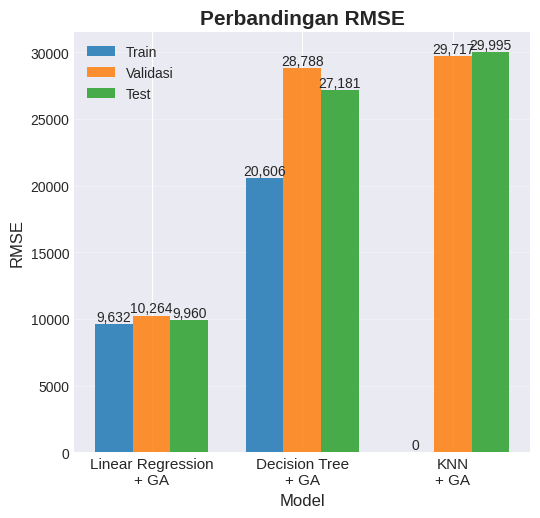

In [21]:
plt.figure(figsize=(20, 12))

ax1 = plt.subplot(2, 3, 1)
x = np.arange(len(models))
width = 0.25

bars1 = ax1.bar(x - width, train_rmse, width, label='Train', alpha=0.85)
bars2 = ax1.bar(x, val_rmse, width, label='Validasi', alpha=0.85)
bars3 = ax1.bar(x + width, test_rmse, width, label='Test', alpha=0.85)

ax1.set_title('Perbandingan RMSE', fontsize=15, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{bar.get_height():,.0f}',
            ha='center',
            va='bottom',
            fontsize=10
        )


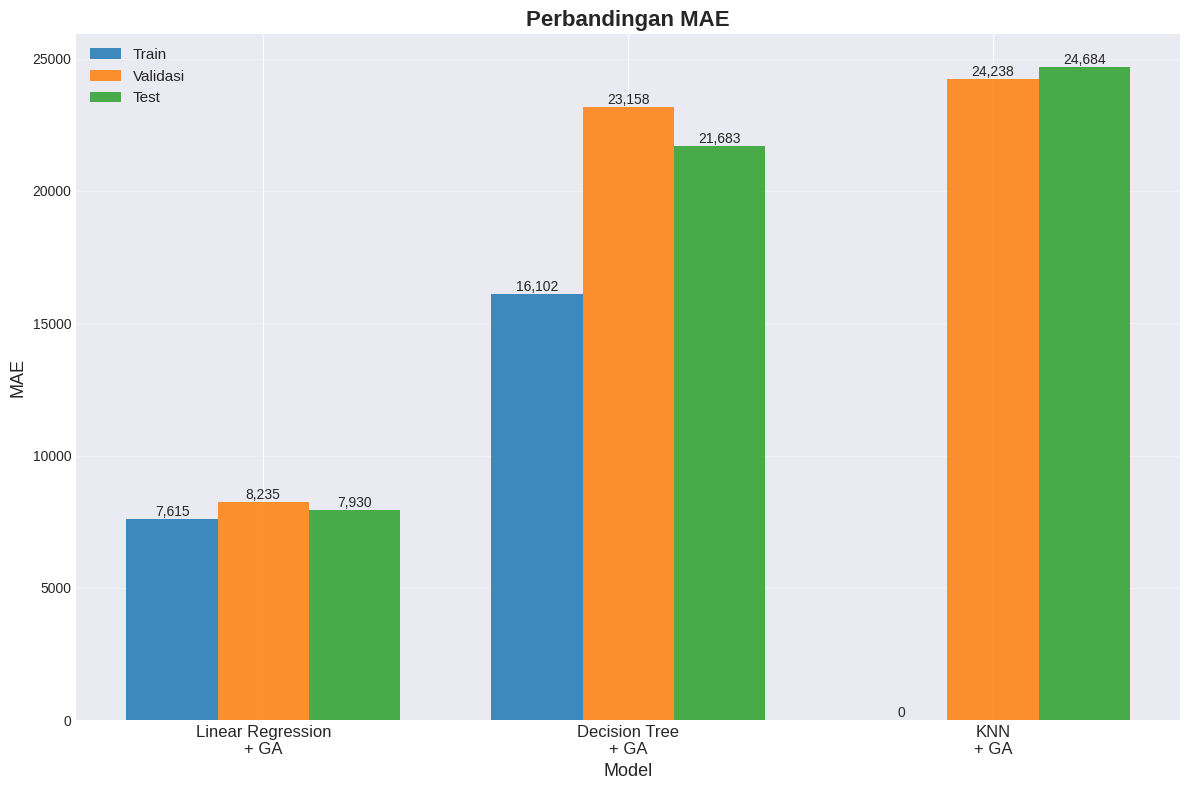

In [22]:
plt.figure(figsize=(12, 8))

bars1 = plt.bar(x - width, train_mae, width, label='Train', alpha=0.85)
bars2 = plt.bar(x, val_mae, width, label='Validasi', alpha=0.85)
bars3 = plt.bar(x + width, test_mae, width, label='Test', alpha=0.85)

plt.title('Perbandingan MAE', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('MAE', fontsize=13)
plt.xticks(x, models, fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{bar.get_height():,.0f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.show()


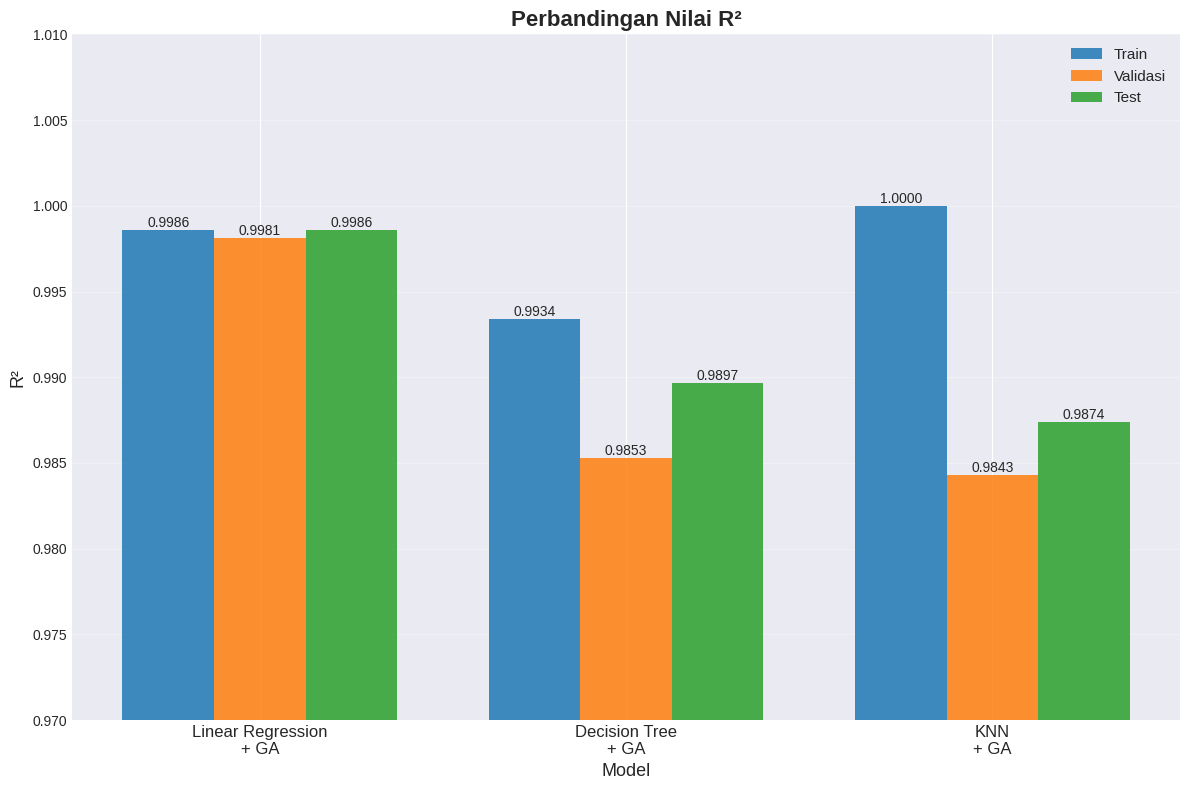

In [23]:
plt.figure(figsize=(12, 8))

bars1 = plt.bar(x - width, train_r2, width, label='Train', alpha=0.85)
bars2 = plt.bar(x, val_r2, width, label='Validasi', alpha=0.85)
bars3 = plt.bar(x + width, test_r2, width, label='Test', alpha=0.85)

plt.title('Perbandingan Nilai R²', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('R²', fontsize=13)
plt.ylim(0.97, 1.01)
plt.xticks(x, models, fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{bar.get_height():.4f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.show()


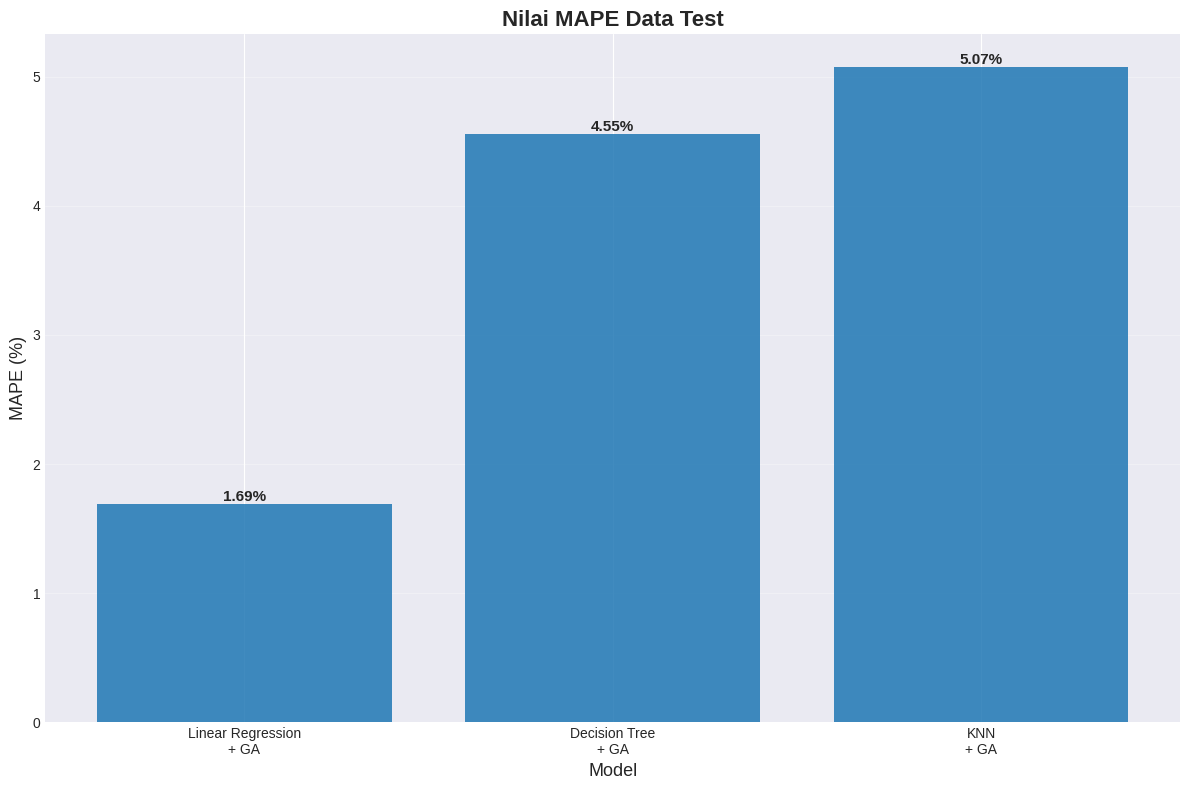

In [24]:
plt.figure(figsize=(12, 8))

bars = plt.bar(models, test_mape, alpha=0.85)

plt.title('Nilai MAPE Data Test', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('MAPE (%)', fontsize=13)
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, test_mape):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{val:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


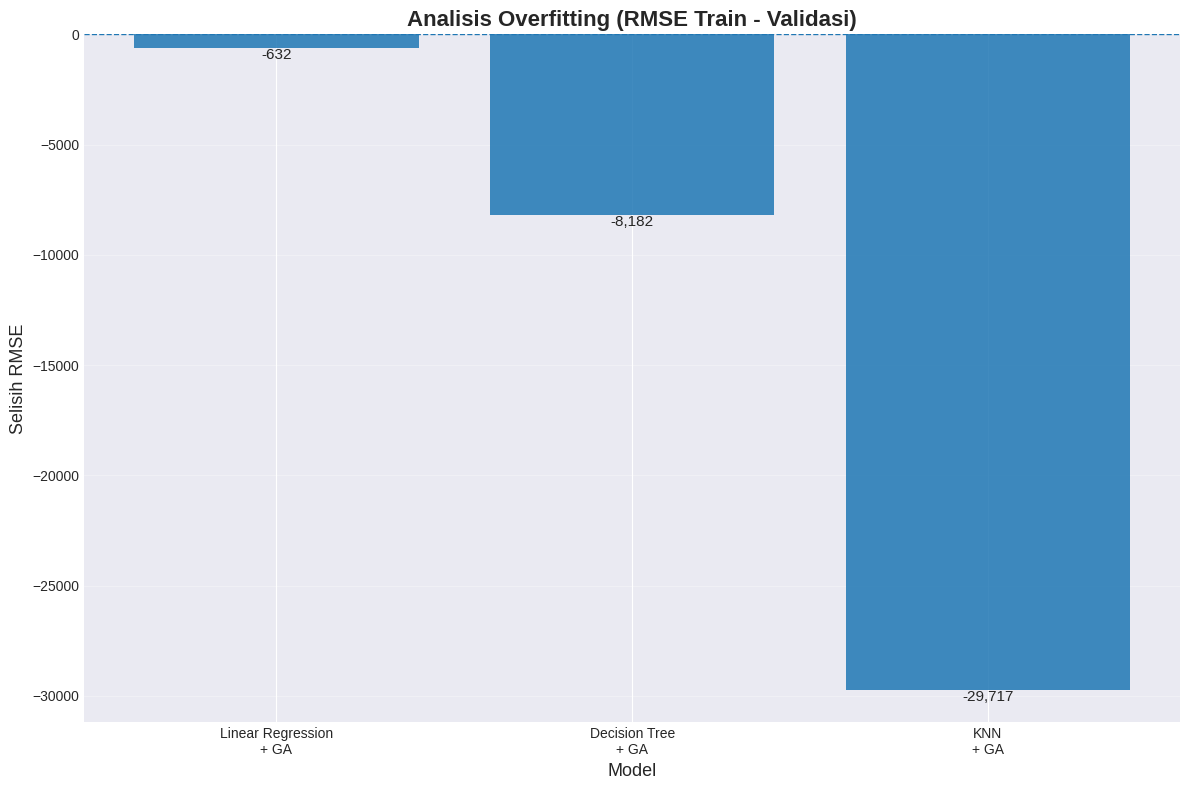

In [25]:
plt.figure(figsize=(12, 8))

selisih_rmse = [train_rmse[i] - val_rmse[i] for i in range(len(models))]
bars = plt.bar(models, selisih_rmse, alpha=0.85)

plt.axhline(0, linestyle='--', linewidth=1)
plt.title('Analisis Overfitting (RMSE Train - Validasi)', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('Selisih RMSE', fontsize=13)
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, selisih_rmse):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{val:,.0f}',
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontsize=11
    )

plt.tight_layout()
plt.show()


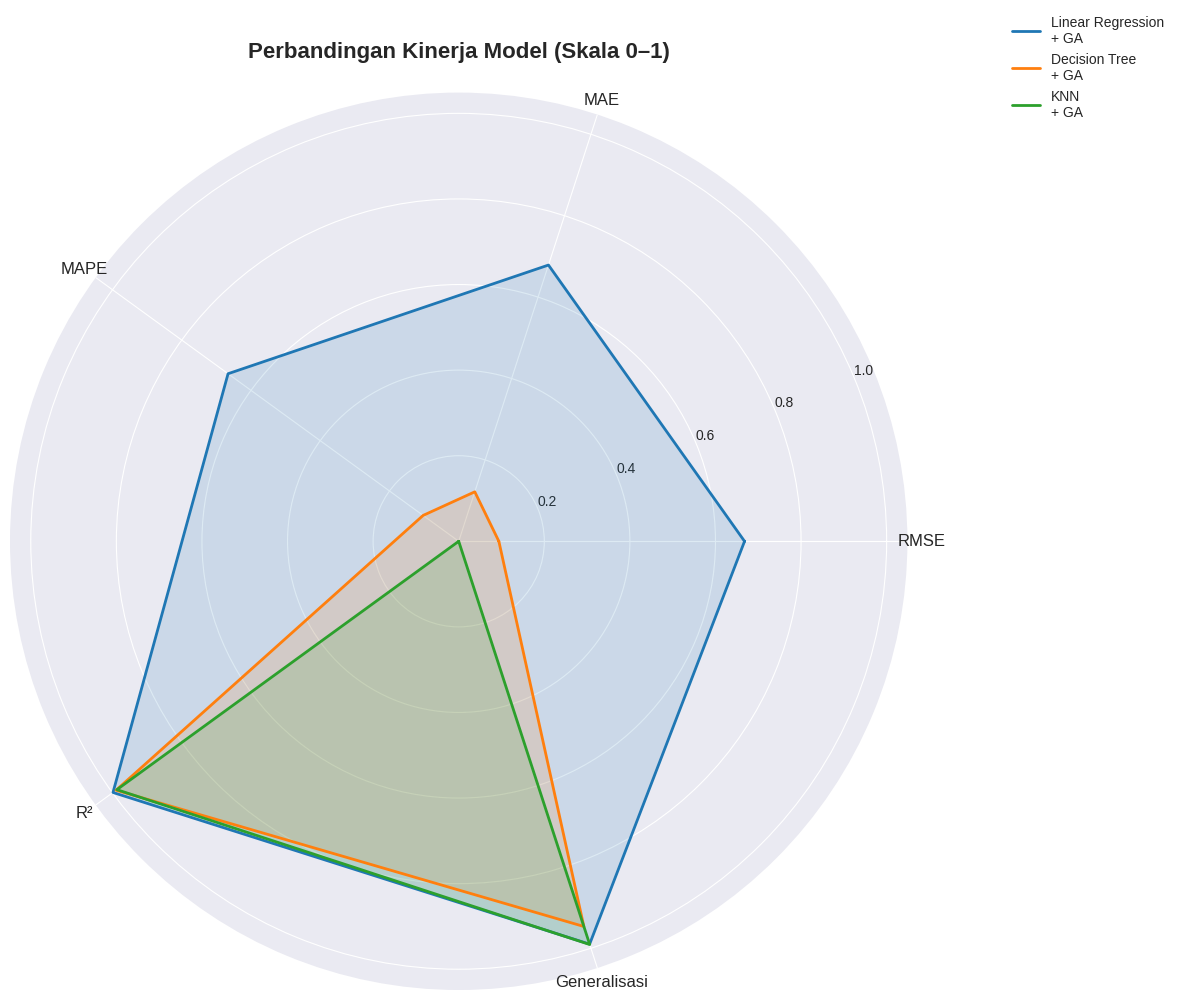

In [26]:
plt.figure(figsize=(12, 10))
ax = plt.subplot(111, polar=True)

kategori = ['RMSE', 'MAE', 'MAPE', 'R²', 'Generalisasi']
jumlah = len(kategori)

sudut = np.linspace(0, 2 * np.pi, jumlah, endpoint=False).tolist()
sudut += sudut[:1]

for i, model in enumerate(models):
    nilai = [
        1 - test_rmse[i] / max(test_rmse),
        1 - test_mae[i] / max(test_mae),
        1 - test_mape[i] / max(test_mape),
        test_r2[i],
        1 - abs(val_rmse[i] - test_rmse[i]) / max(test_rmse)
    ]
    nilai += nilai[:1]

    ax.plot(sudut, nilai, linewidth=2, label=model)
    ax.fill(sudut, nilai, alpha=0.15)

ax.set_thetagrids(np.degrees(sudut[:-1]), kategori, fontsize=12)
ax.set_title('Perbandingan Kinerja Model (Skala 0–1)', fontsize=16, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()


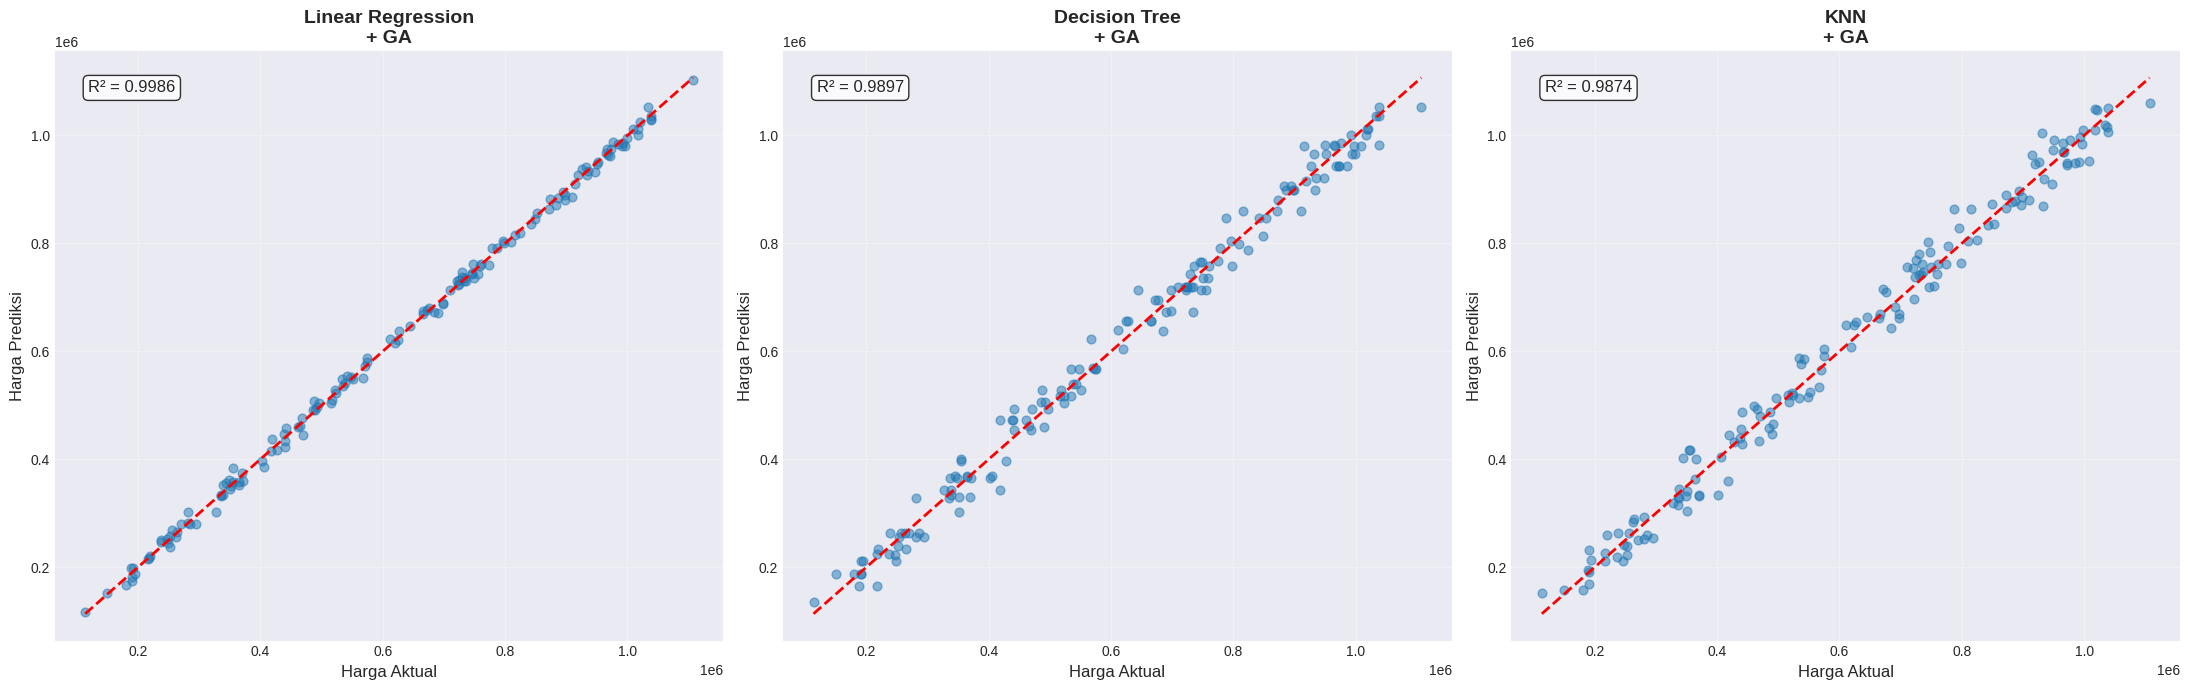

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
predictions_list = [lr_test_pred, dt_test_pred, knn_test_pred]
r2_test_values  = [lr_test_r2,  dt_test_r2,  knn_test_r2]

for ax, pred, model, r2_val in zip(axes, predictions_list, models, r2_test_values):
    ax.scatter(y_test, pred, alpha=0.5, s=40)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', linewidth=2)

    ax.set_title(model, fontsize=14, fontweight='bold')
    ax.set_xlabel('Harga Aktual', fontsize=12)
    ax.set_ylabel('Harga Prediksi', fontsize=12)
    ax.grid(True, alpha=0.3)

    ax.text(
        0.05, 0.95,
        f'R² = {r2_val:.4f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

plt.tight_layout()
plt.show()


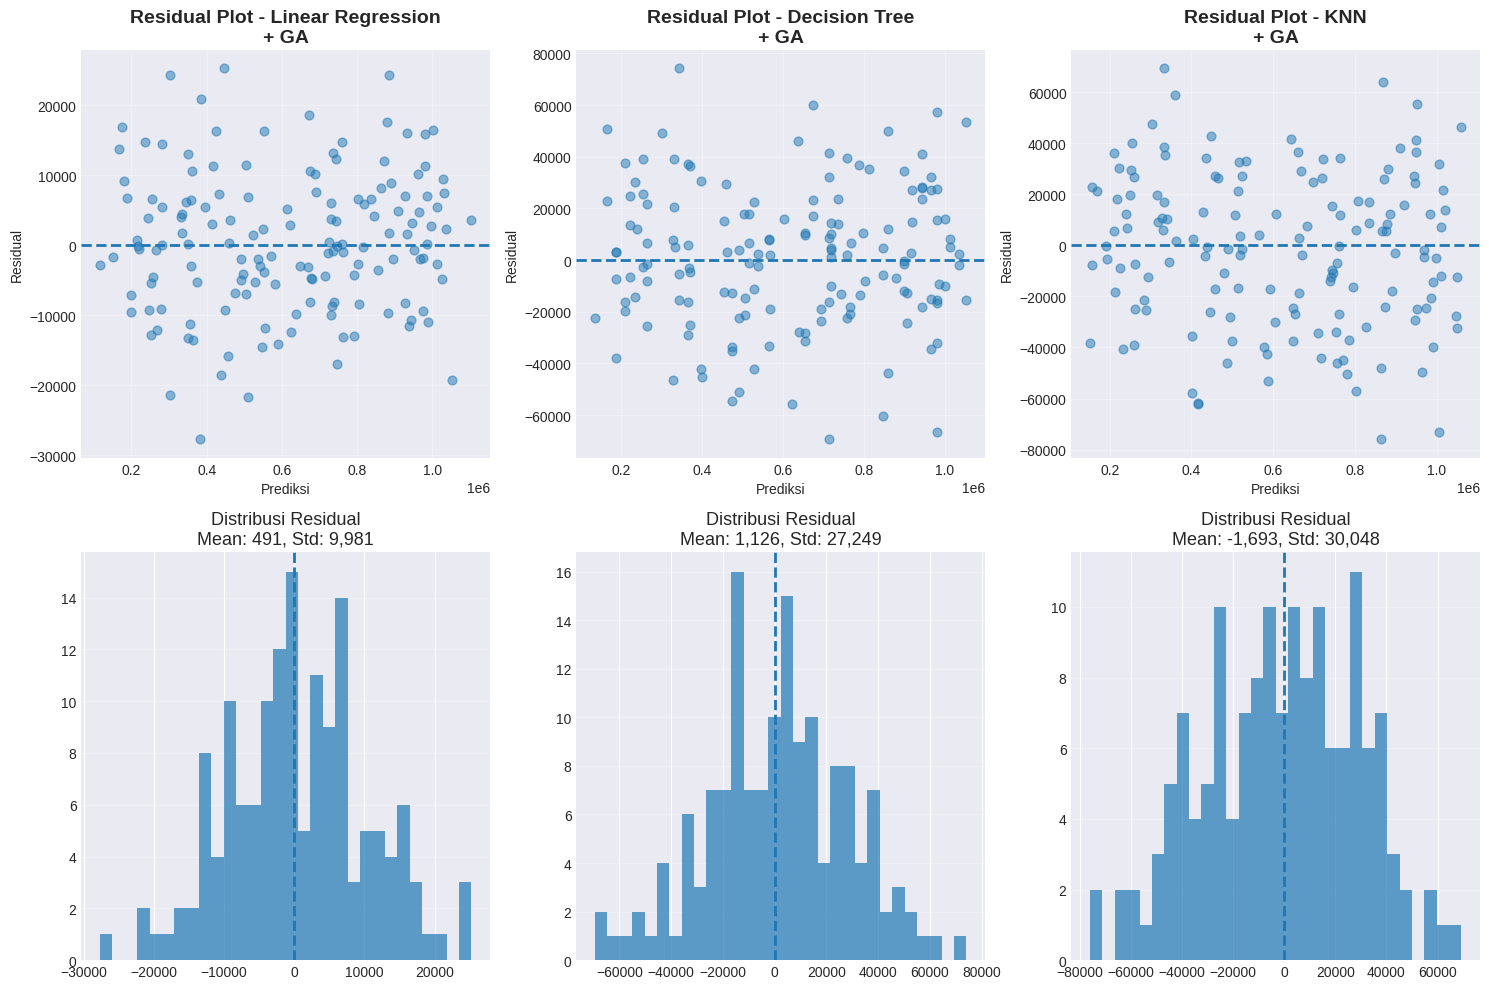

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (pred, model) in enumerate(zip(predictions_list, models)):
    residual = y_test - pred

    axes[0, i].scatter(pred, residual, alpha=0.5, s=40)
    axes[0, i].axhline(0, linestyle='--', linewidth=2)
    axes[0, i].set_title(f'Residual Plot - {model}', fontsize=14, fontweight='bold')
    axes[0, i].set_xlabel('Prediksi')
    axes[0, i].set_ylabel('Residual')
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].hist(residual, bins=30, alpha=0.7)
    axes[1, i].axvline(0, linestyle='--', linewidth=2)
    axes[1, i].set_title(
        f'Distribusi Residual\nMean: {residual.mean():,.0f}, Std: {residual.std():,.0f}',
        fontsize=13
    )
    axes[1, i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 8.4 Interpretasi Visualisasi

1. Grafik Perbandingan RMSE (Train/Validation/Test):
- Membandingkan error pada ketiga dataset secara bersamaan
- Model yang baik memiliki nilai RMSE yang konsisten di ketiganya
- Gap besar antara Train dan Val/Test mengindikasikan overfitting
- Catatan: Train RMSE = 0 untuk KNN adalah normal (lihat penjelasan sebelumnya)

2. Grafik R² Score:
- Menunjukkan seberapa baik model menjelaskan variasi data target
- R² mendekati 1.0 menandakan prediksi yang sangat akurat
- R² > 0.9 umumnya dianggap sangat baik untuk masalah regresi

3. Grafik MAPE (Mean Absolute Percentage Error):
- Menunjukkan rata-rata persentase error prediksi
- MAPE < 10% umumnya dianggap akurat
- Mudah dikomunikasikan: "Error rata-rata adalah X% dari harga aktual"

4. Analisis Overfitting (Selisih RMSE Train - Validation):
- Nilai negatif besar: Train RMSE jauh lebih kecil dari Val RMSE → kemungkinan overfitting
- Nilai mendekati 0: Performa train dan validation seimbang → generalisasi baik
- Nilai positif: Train RMSE > Val RMSE → kondisi tidak biasa, mungkin underfitting

5. Radar Chart (Spider Plot):
- Memberikan perbandingan multi-dimensi dari semua metrik
- Model dengan area lebih luas memiliki performa keseluruhan lebih baik
- Memudahkan melihat trade-off: model A mungkin unggul di metrik X tapi kalah di metrik Y

6. Scatter Plot Actual vs Predicted:
- Titik yang dekat dengan garis diagonal menunjukkan prediksi akurat
- Penyebaran titik yang merata di sekitar garis menunjukkan model tidak bias
- Pola sistematis (melengkung, mengelompok) mengindikasikan model tidak menangkap semua pola

7. Residual Analysis:
- Residual Plot: Residual (error) harus tersebar random di sekitar garis 0
- Pola sistematis pada residual plot mengindikasikan ada pola yang tidak tertangkap
- Histogram Residual: Idealnya berbentuk distribusi normal dengan mean ≈ 0
- Std residual yang kecil menandakan prediksi yang konsisten



# 9. KESIMPULAN

Berdasarkan serangkaian eksperimen yang telah dilakukan, berikut adalah kesimpulan komprehensif dari penelitian ini:

## 9.1 Pengaruh Genetic Algorithm terhadap Performa Model

Penerapan Genetic Algorithm (GA) terbukti efektif dalam mengoptimasi model prediksi harga rumah. GA berhasil melakukan:

1. Feature Selection Otomatis: GA secara cerdas memilih subset fitur yang paling relevan dari 7 fitur yang tersedia. Hasil menunjukkan bahwa tidak semua fitur diperlukan untuk menghasilkan prediksi optimal.

2. Hyperparameter Tuning: Untuk model KNN dan Decision Tree, GA menemukan kombinasi hyperparameter yang optimal tanpa perlu melakukan exhaustive grid search yang memakan waktu.

3. Efisiensi Komputasi: Dibandingkan dengan brute-force search, GA dapat menemukan solusi yang baik dalam waktu yang jauh lebih singkat karena prinsip evolusi yang terarah.

## 9.2 Perbandingan Kinerja Model

Berdasarkan evaluasi pada data uji (test set), model dengan nilai RMSE paling rendah menunjukkan kinerja terbaik. Analisis mendalam menunjukkan:

- Linear Regression diharapkan memberikan performa terbaik karena hubungan antara fitur utama (Square_Footage) dan target (House_Price) bersifat hampir perfectly linear (korelasi 0.991)
- Model kompleks seperti Decision Tree dan KNN tidak selalu lebih baik jika pola data sudah sederhana (linear)
- Trade-off kompleksitas vs akurasi: Model sederhana yang cocok dengan pola data lebih baik daripada model kompleks yang tidak sesuai

## 9.3 Analisis Overfitting dan Generalisasi

Perbedaan nilai error (RMSE) pada data training, validation, dan test menunjukkan:

- Model tidak mengalami overfitting yang signifikan jika gap antara Train dan Val/Test RMSE kecil
- Konsistensi antara Val RMSE dan Test RMSE mengindikasikan kemampuan generalisasi yang baik
- Penggunaan validation set terpisah untuk fitness GA membantu mencegah overfitting selama optimasi

## 9.4 Hasil Feature Selection

Hasil feature selection menggunakan GA mengkonfirmasi temuan dari analisis korelasi:

- Square_Footage secara konsisten terpilih sebagai fitur paling penting oleh semua model
- Fitur-fitur dengan korelasi rendah (< 0.2) cenderung tidak dipilih atau memiliki kontribusi minimal
- Hal ini menunjukkan bahwa GA efektif dalam mengidentifikasi fitur yang benar-benar relevan

## 9.5 Implikasi Praktis

Dari perspektif aplikasi praktis:

1. Untuk Deployment: Model terbaik dapat digunakan untuk membantu estimasi harga rumah dalam sistem penilaian properti

2. Interpretabilitas: Dominasi Square_Footage memberikan insight bisnis yang jelas: "Luas bangunan adalah faktor paling menentukan harga rumah dalam dataset ini"

3. Efisiensi Data: Tidak semua fitur perlu dikumpulkan; cukup fokus pada fitur-fitur yang terbukti berpengaruh

## 9.6 Rekomendasi

Berdasarkan hasil penelitian, direkomendasikan:

1. Gunakan model terbaik (berdasarkan Test RMSE terendah) untuk deployment
2. Fokus pada fitur-fitur utama yang terpilih oleh GA untuk pengumpulan data di masa depan
3. Pertimbangkan Linear Regression sebagai baseline karena kesederhanaannya dan kesesuaiannya dengan pola data
4. Monitor performa secara berkala karena pola data properti dapat berubah seiring waktu

Kesimpulan Akhir: Penggunaan Genetic Algorithm sebagai metode optimasi terbukti efektif dalam meningkatkan kinerja model prediksi harga rumah. Kombinasi feature selection dan hyperparameter tuning oleh GA menghasilkan model yang akurat, efisien, dan memiliki generalisasi yang baik.
